# Imports and configs

In [1]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, classification_report

from scipy.fft import rfft, rfftfreq
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = ['MS Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

import seaborn as sns
import pandas as pd
import numpy as np
import polars as pl
import warnings
import optuna
import joblib
import glob
import gc
import time
from tqdm import tqdm
import os

warnings.filterwarnings("ignore")

In [2]:
class CFG:
    train_path = "input/train.csv"
    train_demographic_path = "input/train_demographics.csv"
    test_path = "input/test.csv"
    test_demographic_path = "input/test_demographics.csv"

    target = "gesture"
    
    n_folds = 3
    seed = 42

    run_optuna = True
    n_optuna_trials = 100 

# Data loading

In [3]:
train = pd.read_csv(CFG.train_path).reset_index(drop=True)
train_d = pd.read_csv(CFG.train_demographic_path).reset_index(drop=True)
test = pd.read_csv(CFG.test_path).reset_index(drop=True)
test_d = pd.read_csv(CFG.test_demographic_path).reset_index(drop=True)

# Preprocessing

## Base

In [4]:
# Encode target
le_gesture = LabelEncoder()
train["e_gesture"] = le_gesture.fit_transform(train["gesture"])

In [5]:
# rotが欠損しているsequenceは除外
rot_cols = [col for col in train.columns if col.startswith('rot_')]

rot_null_row_train = train[rot_cols].isnull().any(axis=1)
rot_null_sequence_ids_train = train.loc[rot_null_row_train, 'sequence_id'].unique()
rot_null_row_test = test[rot_cols].isnull().any(axis=1)
rot_null_sequence_ids_test = test.loc[rot_null_row_test, 'sequence_id'].unique()

train = train[~train['sequence_id'].isin(rot_null_sequence_ids_train)].reset_index(drop=True)
test = test[~test['sequence_id'].isin(rot_null_sequence_ids_test)].reset_index(drop=True)

print(f"=== rot null sequence count ===")
print(f"train: {len(rot_null_sequence_ids_train)}")
print(f"test: {len(rot_null_sequence_ids_test)}")


=== rot null sequence count ===
train: 50
test: 0


In [6]:
# thm, tofのいずれか1つでもNaNがあればIMU-only
thm_cols = [col for col in train.columns if col.startswith('thm_')]
tof_cols = [col for col in train.columns if col.startswith('tof_')]

thm_null_row_train = train[thm_cols].isnull().any(axis=1)
thm_null_sequence_ids_train = train.loc[thm_null_row_train, 'sequence_id'].unique()

print(f"thm null sequence count: {len(thm_null_sequence_ids_train)}")

tof_null_row_train = train[tof_cols].isnull().any(axis=1)
tof_null_sequence_ids_train = train.loc[tof_null_row_train, 'sequence_id'].unique()

print(f"tof null sequence count: {len(tof_null_sequence_ids_train)}")

imu_only_seq_ids = list(set(thm_null_sequence_ids_train) | set(tof_null_sequence_ids_train))
full_data_seq_ids = train[~train['sequence_id'].isin(imu_only_seq_ids)]['sequence_id'].unique()

# Set thermal and ToF columns to NaN for IMU-only sequences
train.loc[train['sequence_id'].isin(imu_only_seq_ids), thm_cols+tof_cols] = np.nan

print(f"imu only seq count: {len(imu_only_seq_ids)}")
print(f"full data seq count: {len(full_data_seq_ids)}")

thm null sequence count: 508
tof null sequence count: 435
imu only seq count: 508
full data seq count: 7593


In [7]:
# full dataからimu only用のデータを作成
train_imu_only = train.copy()
train_imu_only[thm_cols+tof_cols] = np.nan

train_imu_only.isnull().sum()

row_id                   0
sequence_type            0
sequence_id              0
sequence_counter         0
subject                  0
                     ...  
tof_5_v60           571253
tof_5_v61           571253
tof_5_v62           571253
tof_5_v63           571253
e_gesture                0
Length: 342, dtype: int64

In [8]:
def create_balanced_lightweight_dataset(train, sequences_per_gesture=100):
    """
    各ジェスチャーから指定数のシーケンスをバランス良く抽出
    """
    print("=== バランス軽量化データセット作成 ===")
    
    selected_sequences = []
    gesture_info = []
    
    # 各ジェスチャーから指定数のシーケンスを選択
    for gesture in le_gesture.classes_:
        # 該当ジェスチャーのシーケンスID取得
        gesture_sequences = train[train['gesture'] == gesture]['sequence_id'].unique()
        available_count = len(gesture_sequences)
        
        print(f"{gesture}: {available_count} sequences available")
        
        # 指定数まで選択（利用可能数が少ない場合は全て選択）
        n_to_select = min(sequences_per_gesture, available_count)
        
        # ランダムサンプリング（再現性のため乱数シード固定）
        np.random.seed(CFG.seed)
        selected = np.random.choice(gesture_sequences, n_to_select, replace=False)
        selected_sequences.extend(selected)
        
        gesture_info.append({
            'gesture': gesture,
            'available': available_count,
            'selected': n_to_select
        })
    
    # 選択されたシーケンスでデータを絞り込み
    train_balanced = train[train['sequence_id'].isin(selected_sequences)].copy()
    
    # 結果サマリー
    print(f"\n=== 軽量化結果 ===")
    print(f"総シーケンス数: {len(selected_sequences)}")
    print(f"元データからの削減率: {(1 - len(selected_sequences)/len(train['sequence_id'].unique())):.1%}")
    
    # ジェスチャー別サマリー
    gesture_summary = pd.DataFrame(gesture_info)
    print(f"\nジェスチャー別選択数:")
    for _, row in gesture_summary.iterrows():
        print(f"  {row['gesture']}: {row['selected']}/{row['available']}")
    
    # IMU-only vs Full-sensor比率確認
    imu_sequences = train_balanced[train_balanced['sequence_id'].isin(imu_only_seq_ids)]['sequence_id'].nunique()
    full_sequences = train_balanced[~train_balanced['sequence_id'].isin(imu_only_seq_ids)]['sequence_id'].nunique()
    
    print(f"\n=== センサータイプ分布 ===")
    print(f"IMU-only: {imu_sequences} sequences ({imu_sequences/len(selected_sequences):.1%})")
    print(f"Full-sensor: {full_sequences} sequences ({full_sequences/len(selected_sequences):.1%})")
    
    # 被験者分布確認
    selected_subjects = train_balanced['subject'].nunique()
    total_subjects = train['subject'].nunique()
    print(f"\n=== 被験者分布 ===")
    print(f"対象被験者数: {selected_subjects}/{total_subjects}")
    
    return train_balanced, selected_sequences

In [9]:
# バランス軽量化実行
train_balanced, selected_sequences = create_balanced_lightweight_dataset(
    train, sequences_per_gesture=100
)

=== バランス軽量化データセット作成 ===
Above ear - pull hair: 634 sequences available
Cheek - pinch skin: 633 sequences available
Drink from bottle/cup: 161 sequences available
Eyebrow - pull hair: 634 sequences available
Eyelash - pull hair: 636 sequences available
Feel around in tray and pull out an object: 161 sequences available
Forehead - pull hairline: 636 sequences available
Forehead - scratch: 636 sequences available
Glasses on/off: 161 sequences available
Neck - pinch skin: 636 sequences available
Neck - scratch: 634 sequences available
Pinch knee/leg skin: 161 sequences available
Pull air toward your face: 473 sequences available
Scratch knee/leg skin: 161 sequences available
Text on phone: 636 sequences available
Wave hello: 474 sequences available
Write name in air: 473 sequences available
Write name on leg: 161 sequences available

=== 軽量化結果 ===
総シーケンス数: 1800
元データからの削減率: 77.8%

ジェスチャー別選択数:
  Above ear - pull hair: 100/634
  Cheek - pinch skin: 100/633
  Drink from bottle/cup: 100/161
  E

In [10]:
def feature_set(df: pd.DataFrame, use_extra: bool = False) -> dict:
    """
    Extracts an enhanced set of features from sensor data for gesture prediction.

    Features include:
    - Basic statistics (mean, std, min, max, median)
    - Advanced statistics (energy, range, quantiles, skew, kurtosis)
    - Peak detection for IMU signals
    - Frequency band energy from FFT
    - Aggregated thermal and ToF features (max/std, rate of change)
    """
    feats = {}
    imu_cols = [c for c in df.columns if any(x in c for x in ['acc_', 'rot_'])]

    # Vector magnitudes and jerk features
    df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
    df['rot_mag'] = np.sqrt(df['rot_x']**2 + df['rot_y']**2 + df['rot_z']**2)
    df['acc_jerk_x'] = df['acc_x'].diff().fillna(0)
    df['acc_jerk_y'] = df['acc_y'].diff().fillna(0)
    df['acc_jerk_z'] = df['acc_z'].diff().fillna(0)
    imu_cols.extend(['acc_mag', 'rot_mag', 'acc_jerk_x', 'acc_jerk_y', 'acc_jerk_z'])

    # Feature Extraction for IMU Sensors
    for col in imu_cols:
        arr = df[col].values
        # Basic Statistics
        feats[f'{col}_mean'] = np.mean(arr)
        feats[f'{col}_std'] = np.std(arr)
        feats[f'{col}_min'] = np.min(arr)
        feats[f'{col}_max'] = np.max(arr)
        feats[f'{col}_median'] = np.median(arr)
        feats[f'{col}_range'] = feats[f'{col}_max'] - feats[f'{col}_min']
        # Advanced Statistics
        feats[f'{col}_q25'] = np.quantile(arr, 0.25)
        feats[f'{col}_q75'] = np.quantile(arr, 0.75)
        feats[f'{col}_energy'] = np.sum(arr**2) / len(arr)
        feats[f'{col}_skew'] = skew(arr)
        feats[f'{col}_kurtosis'] = kurtosis(arr)
        # Rolling Window Features
        for window in [5, 10, 15, 20, 25, 50]:
            rolling_mean = df[col].rolling(window=window, min_periods=1).mean()
            rolling_std = df[col].rolling(window=window, min_periods=1).std().fillna(0)
            feats[f'{col}_roll_mean_{window}_mean'] = rolling_mean.mean()
            feats[f'{col}_roll_std_{window}_mean'] = rolling_std.mean()
        # Frequency Domain Features (FFT)
        fft_vals = rfft(arr)
        fft_mags = np.abs(fft_vals)
        if len(fft_mags) > 1:
            feats[f'{col}_fft_mean'] = np.mean(fft_mags)
            feats[f'{col}_fft_max'] = np.max(fft_mags)
            freqs = rfftfreq(len(arr))
            feats[f'{col}_fft_dominant_freq'] = freqs[np.argmax(fft_mags[1:]) + 1] if len(fft_mags) > 1 else 0
            # Energy in Frequency Bands
            bands = [(0, 2), (2, 5), (5, 10)]
            for low, high in bands:
                mask = (freqs >= low) & (freqs < high)
                feats[f'{col}_fft_energy_{low}_{high}'] = np.sum(fft_mags[mask])
        # Peak Detection
        peaks, _ = find_peaks(arr, height=0)
        feats[f'{col}_num_peaks'] = len(peaks) / len(arr)

    # Cross-Sensor Correlations
    for (c1, c2) in [('acc_x', 'acc_y'), ('acc_x', 'acc_z'), ('acc_y', 'acc_z'),
                     ('rot_x', 'rot_y'), ('rot_x', 'rot_z'), ('rot_y', 'rot_z')]:
        if c1 in df.columns and c2 in df.columns:
            feats[f'{c1}_{c2}_corr'] = np.corrcoef(df[c1], df[c2])[0, 1]

    # Extra Sensor Features (Thermal & ToF)
    if use_extra:
        thm_cols = [c for c in df.columns if 'thm' in c]
        tof_cols = [c for c in df.columns if 'tof' in c]
        # Thermal Features
        if thm_cols:
            thm_data = df[thm_cols].values
            feats['thm_max_across_sensors'] = np.nanmax(thm_data, axis=1).mean()
            feats['thm_std_across_sensors'] = np.nanstd(thm_data, axis=1).mean()
            for col in thm_cols:
                feats[f'{col}_mean'] = np.nanmean(df[col])
                feats[f'{col}_max'] = np.nanmax(df[col])
                feats[f'{col}_diff_mean'] = df[col].diff().abs().mean()
        # ToF Features
        if tof_cols:
            tof_data = df[tof_cols].values
            valid_tof = tof_data >= 0
            min_tof_per_time = np.min(tof_data, axis=1, where=valid_tof, initial=10000)
            feats['tof_min_across_sensors'] = np.mean(min_tof_per_time)
            feats['tof_num_valid_sensors'] = np.sum(valid_tof, axis=1).mean()
            for col in tof_cols:
                valid_vals = df[col][df[col] >= 0]
                if valid_vals.size > 0:
                    feats[f'{col}_mean'] = np.mean(valid_vals)
                    feats[f'{col}_min'] = np.min(valid_vals)
                    feats[f'{col}_diff_mean'] = df[col].diff().abs().mean()

    return feats

In [11]:
def build_features(data: pd.DataFrame, demographics: pd.DataFrame, use_extra: bool) -> tuple[pd.DataFrame, list]:
    """Builds feature matrix and returns features with subject groups for CV."""
    features = []
    groups = []
    for seq_id, g in data.groupby('sequence_id'):
        subj = g['subject'].iloc[0]
        groups.append(subj)
        feats = feature_set(g, use_extra=use_extra)
        feats['sequence_id'] = seq_id
        demo_row = demographics[demographics['subject'] == subj]
        if not demo_row.empty:
            demo = demo_row.iloc[0]
            for dcol in ['age', 'sex', 'height_cm', 'handedness']:
                feats[dcol] = demo.get(dcol, np.nan)
        features.append(feats)
    df_feats = pd.DataFrame(features).set_index('sequence_id')
    if 'sex' in df_feats.columns:
        df_feats['sex'] = df_feats['sex'].map({'M': 1, 'F': 0})
    if 'handedness' in df_feats.columns:
        df_feats['handedness'] = df_feats['handedness'].map({'R': 1, 'L': 0, 'A': 2})
    
    return df_feats, groups

In [12]:
def create_balanced_feature_datasets(train_balanced, train_d):
    """
    軽量化されたデータから特徴量セットを作成
    """
    print("=== 軽量化特徴量セット作成 ===")
    
    # IMU-only用データ作成
    train_imu_balanced = train_balanced.copy()
    train_imu_balanced[thm_cols + tof_cols] = np.nan
    
    # Full-sensor用データ作成（元々full-sensorがあるシーケンスのみ）
    full_sensor_sequences = train_balanced[
        ~train_balanced['sequence_id'].isin(imu_only_seq_ids)
    ]['sequence_id'].unique()
    
    print(f"IMU-only対象: {len(train_imu_balanced['sequence_id'].unique())} sequences")
    print(f"Full-sensor対象: {len(full_sensor_sequences)} sequences")
    
    # 特徴量構築
    print("IMU-only特徴量構築中...")
    X_imu_balanced, groups_imu_balanced = build_features(
        train_imu_balanced, train_d, use_extra=False
    )
    y_imu_balanced = train_imu_balanced.groupby('sequence_id')['e_gesture'].first().loc[X_imu_balanced.index]
    
    print("Full-sensor特徴量構築中...")
    X_full_balanced, groups_full_balanced = build_features(
        train_balanced[train_balanced['sequence_id'].isin(full_sensor_sequences)], 
        train_d, use_extra=True
    )
    y_full_balanced = train_balanced.groupby('sequence_id')['e_gesture'].first().loc[X_full_balanced.index]
    
    print(f"\n=== 特徴量セット完成 ===")
    print(f"IMU-only: {X_imu_balanced.shape} (samples × features)")
    print(f"Full-sensor: {X_full_balanced.shape} (samples × features)")
    
    return (X_imu_balanced, y_imu_balanced, groups_imu_balanced, 
            X_full_balanced, y_full_balanced, groups_full_balanced)

In [13]:
# 特徴量セット作成
(X_imu_bal, y_imu_bal, groups_imu_bal, 
 X_full_bal, y_full_bal, groups_full_bal) = create_balanced_feature_datasets(train_balanced, train_d)

=== 軽量化特徴量セット作成 ===
IMU-only対象: 1800 sequences
Full-sensor対象: 1681 sequences
IMU-only特徴量構築中...
Full-sensor特徴量構築中...

=== 特徴量セット完成 ===
IMU-only: (1800, 370) (samples × features)
Full-sensor: (1681, 1349) (samples × features)


## TOF Analysis

In [84]:
def calculate_single_tof_sensor_stats(seq_data, sensor_id, sensor_direction):
    """
    単一ToFセンサーの統計値計算
    """
    sensor_cols = [col for col in seq_data.columns if f'tof_{sensor_id}_' in col]
    
    if not sensor_cols:
        return create_empty_sensor_stats(sensor_direction)
    
    # このセンサーの全有効値を収集
    sensor_values = []
    for col in sensor_cols:
        valid_vals = seq_data[col][seq_data[col] >= 0]
        sensor_values.extend(valid_vals.tolist())
    
    if len(sensor_values) > 0:
        return {
            'mean': np.mean(sensor_values),
            'median': np.median(sensor_values),
            'min': np.min(sensor_values),
            'max': np.max(sensor_values),
            'range': np.max(sensor_values) - np.min(sensor_values),
            'std': np.std(sensor_values),
            'count': len(sensor_values),
            'direction': sensor_direction
        }
    else:
        return create_empty_sensor_stats(sensor_direction)


def create_empty_sensor_stats(sensor_direction):
    """
    有効値がない場合のデフォルト統計値
    """
    return {
        'mean': np.nan,
        'median': np.nan,
        'min': np.nan,
        'max': np.nan,
        'range': np.nan,
        'std': np.nan,
        'count': 0,
        'direction': sensor_direction
    }


def calculate_sequence_sensor_stats(seq_data, sensor_directions):
    """
    単一シーケンスの全ToFセンサー統計値計算
    """
    sequence_sensor_stats = {}
    
    for sensor_id in ['1', '2', '3', '4', '5']:
        sensor_direction = sensor_directions[sensor_id]
        sensor_stats = calculate_single_tof_sensor_stats(seq_data, sensor_id, sensor_direction)
        sequence_sensor_stats[f'tof_{sensor_id}'] = sensor_stats
    
    return sequence_sensor_stats

In [85]:
def analyze_tof_distribution_by_gesture_and_sensor():
    """
    シーケンス単位 & ToFセンサー別ジェスチャー分析
    """
    print("=== シーケンス単位 & ToFセンサー別 ジェスチャー分析 ===")
    
    # センサー方向定義
    sensor_directions = {
        '1': 'CENTER',
        '2': 'PALM_FORWARD', 
        '3': 'RIGHT_SIDE',
        '4': 'WRIST_INNER',
        '5': 'LEFT_SIDE'
    }
    
    gesture_sensor_stats = {}
    
    for gesture in train['gesture'].unique():
        gesture_data = train[train['gesture'] == gesture]
        gesture_sensor_stats[gesture] = {}
        
        # 各シーケンスごとに処理
        for seq_id in gesture_data['sequence_id'].unique():
            seq_data = gesture_data[gesture_data['sequence_id'] == seq_id]
            
            # シーケンスの全センサー統計値を計算
            sequence_sensor_stats = calculate_sequence_sensor_stats(seq_data, sensor_directions)
            
            if sequence_sensor_stats:
                gesture_sensor_stats[gesture][seq_id] = sequence_sensor_stats
        
        # ジェスチャー統計表示
        num_sequences = len(gesture_sensor_stats[gesture])
        print(f"{gesture}: {num_sequences} シーケンス")
    
    return gesture_sensor_stats


gesture_sensor_stats = analyze_tof_distribution_by_gesture_and_sensor()

=== シーケンス単位 & ToFセンサー別 ジェスチャー分析 ===
Cheek - pinch skin: 633 シーケンス
Forehead - pull hairline: 636 シーケンス
Write name on leg: 161 シーケンス
Feel around in tray and pull out an object: 161 シーケンス
Neck - scratch: 634 シーケンス
Neck - pinch skin: 636 シーケンス
Eyelash - pull hair: 636 シーケンス
Eyebrow - pull hair: 634 シーケンス
Forehead - scratch: 636 シーケンス
Above ear - pull hair: 634 シーケンス
Wave hello: 474 シーケンス
Write name in air: 473 シーケンス
Text on phone: 636 シーケンス
Pull air toward your face: 473 シーケンス
Pinch knee/leg skin: 161 シーケンス
Scratch knee/leg skin: 161 シーケンス
Drink from bottle/cup: 161 シーケンス
Glasses on/off: 161 シーケンス


In [ ]:
# def analyze_tof_distribution_by_gesture_and_sensor():
#     """
#     シーケンス単位 & ToFセンサー別でのジェスチャー分布分析
#     """
#     print("=== シーケンス単位 & ToFセンサー別 ジェスチャー分析 ===")
    
#     # センサー方向定義
#     sensor_directions = {
#         '1': 'CENTER',          # 中央
#         '2': 'PALM_FORWARD',    # 手のひら方向（前方/上方向）
#         '3': 'RIGHT_SIDE',      # 右方向  
#         '4': 'WRIST_INNER',     # 手首内側方向（下方向）
#         '5': 'LEFT_SIDE'        # 左方向
#     }
    
#     # 各ジェスチャー別のシーケンス×センサー統計値を収集
#     gesture_sensor_stats = {}
    
#     for gesture in train['gesture'].unique():
#         gesture_data = train[train['gesture'] == gesture]
#         gesture_sensor_stats[gesture] = {}
        
#         # 各シーケンスごとに処理
#         for seq_id in gesture_data['sequence_id'].unique():
#             seq_data = gesture_data[gesture_data['sequence_id'] == seq_id]
#             sequence_sensor_stats = {}
            
#             # 各ToFセンサー（1-5）ごとに統計値計算
#             for sensor_id in ['1', '2', '3', '4', '5']:
#                 sensor_cols = [col for col in seq_data.columns if f'tof_{sensor_id}_' in col]
                
#                 if sensor_cols:
#                     # このセンサーの全有効値を収集
#                     sensor_values = []
#                     for col in sensor_cols:
#                         valid_vals = seq_data[col][seq_data[col] >= 0]
#                         sensor_values.extend(valid_vals.tolist())
                    
#                     if len(sensor_values) > 0:
#                         sequence_sensor_stats[f'tof_{sensor_id}'] = {
#                             'mean': np.mean(sensor_values),
#                             'median': np.median(sensor_values),
#                             'min': np.min(sensor_values),
#                             'max': np.max(sensor_values),
#                             'range': np.max(sensor_values) - np.min(sensor_values),
#                             'std': np.std(sensor_values),
#                             'count': len(sensor_values),
#                             'direction': sensor_directions[sensor_id]
#                         }
#                     else:
#                         # 有効値がない場合のデフォルト
#                         sequence_sensor_stats[f'tof_{sensor_id}'] = {
#                             'mean': np.nan,
#                             'median': np.nan,
#                             'min': np.nan,
#                             'max': np.nan,
#                             'range': np.nan,
#                             'std': np.nan,
#                             'count': 0,
#                             'direction': sensor_directions[sensor_id]
#                         }
            
#             if sequence_sensor_stats:
#                 gesture_sensor_stats[gesture][seq_id] = sequence_sensor_stats
        
#         # ジェスチャー統計表示
#         if gesture in gesture_sensor_stats:
#             num_sequences = len(gesture_sensor_stats[gesture])
#             print(f"{gesture}: {num_sequences} シーケンス")
    
#     return gesture_sensor_stats

# # センサー別分析実行
# gesture_sensor_stats = analyze_tof_distribution_by_gesture_and_sensor()

=== シーケンス単位 & ToFセンサー別 ジェスチャー分析 ===
Cheek - pinch skin: 633 シーケンス
Forehead - pull hairline: 636 シーケンス
Write name on leg: 161 シーケンス
Feel around in tray and pull out an object: 161 シーケンス
Neck - scratch: 634 シーケンス
Neck - pinch skin: 636 シーケンス
Eyelash - pull hair: 636 シーケンス
Eyebrow - pull hair: 634 シーケンス
Forehead - scratch: 636 シーケンス
Above ear - pull hair: 634 シーケンス
Wave hello: 474 シーケンス
Write name in air: 473 シーケンス
Text on phone: 636 シーケンス
Pull air toward your face: 473 シーケンス
Pinch knee/leg skin: 161 シーケンス
Scratch knee/leg skin: 161 シーケンス
Drink from bottle/cup: 161 シーケンス
Glasses on/off: 161 シーケンス


In [75]:
def summarize_gesture_sensor_patterns(gesture_sensor_stats):
    """
    ジェスチャー×センサー別パターンの要約分析
    """    
    gesture_sensor_summary = {}
    
    for gesture, sequences in gesture_sensor_stats.items():
        if len(sequences) >= 5:  # 十分なシーケンス数がある場合のみ
            gesture_sensor_summary[gesture] = {}
            
            # 各センサーごとの統計値を集約
            for sensor_id in ['tof_1', 'tof_2', 'tof_3', 'tof_4', 'tof_5']:
                sensor_medians = []
                sensor_mins = []
                sensor_maxs = []
                sensor_ranges = []
                sensor_means = []
                
                for seq_id, sensor_data in sequences.items():
                    if sensor_id in sensor_data and not np.isnan(sensor_data[sensor_id]['median']):
                        sensor_medians.append(sensor_data[sensor_id]['median'])
                        sensor_mins.append(sensor_data[sensor_id]['min'])
                        sensor_maxs.append(sensor_data[sensor_id]['max'])
                        sensor_ranges.append(sensor_data[sensor_id]['max'] - sensor_data[sensor_id]['min'])
                        sensor_means.append(sensor_data[sensor_id]['mean'])

                
                if len(sensor_medians) > 0:
                    gesture_sensor_summary[gesture][sensor_id] = {
                        'avg_median': np.mean(sensor_medians),
                        'std_median': np.std(sensor_medians),
                        'avg_min': np.mean(sensor_mins),
                        'std_min': np.std(sensor_mins),
                        'avg_max': np.mean(sensor_maxs),
                        'std_max': np.std(sensor_maxs),
                        'avg_range': np.mean(sensor_ranges),
                        'std_range': np.std(sensor_ranges),
                        'avg_mean': np.mean(sensor_means),
                        'std_mean': np.std(sensor_means),
                        'num_valid_sequences': len(sensor_medians),
                        'direction': sequences[list(sequences.keys())[0]][sensor_id]['direction']
                    }
                        
    return gesture_sensor_summary

# パターン要約実行
gesture_sensor_summary = summarize_gesture_sensor_patterns(gesture_sensor_stats)

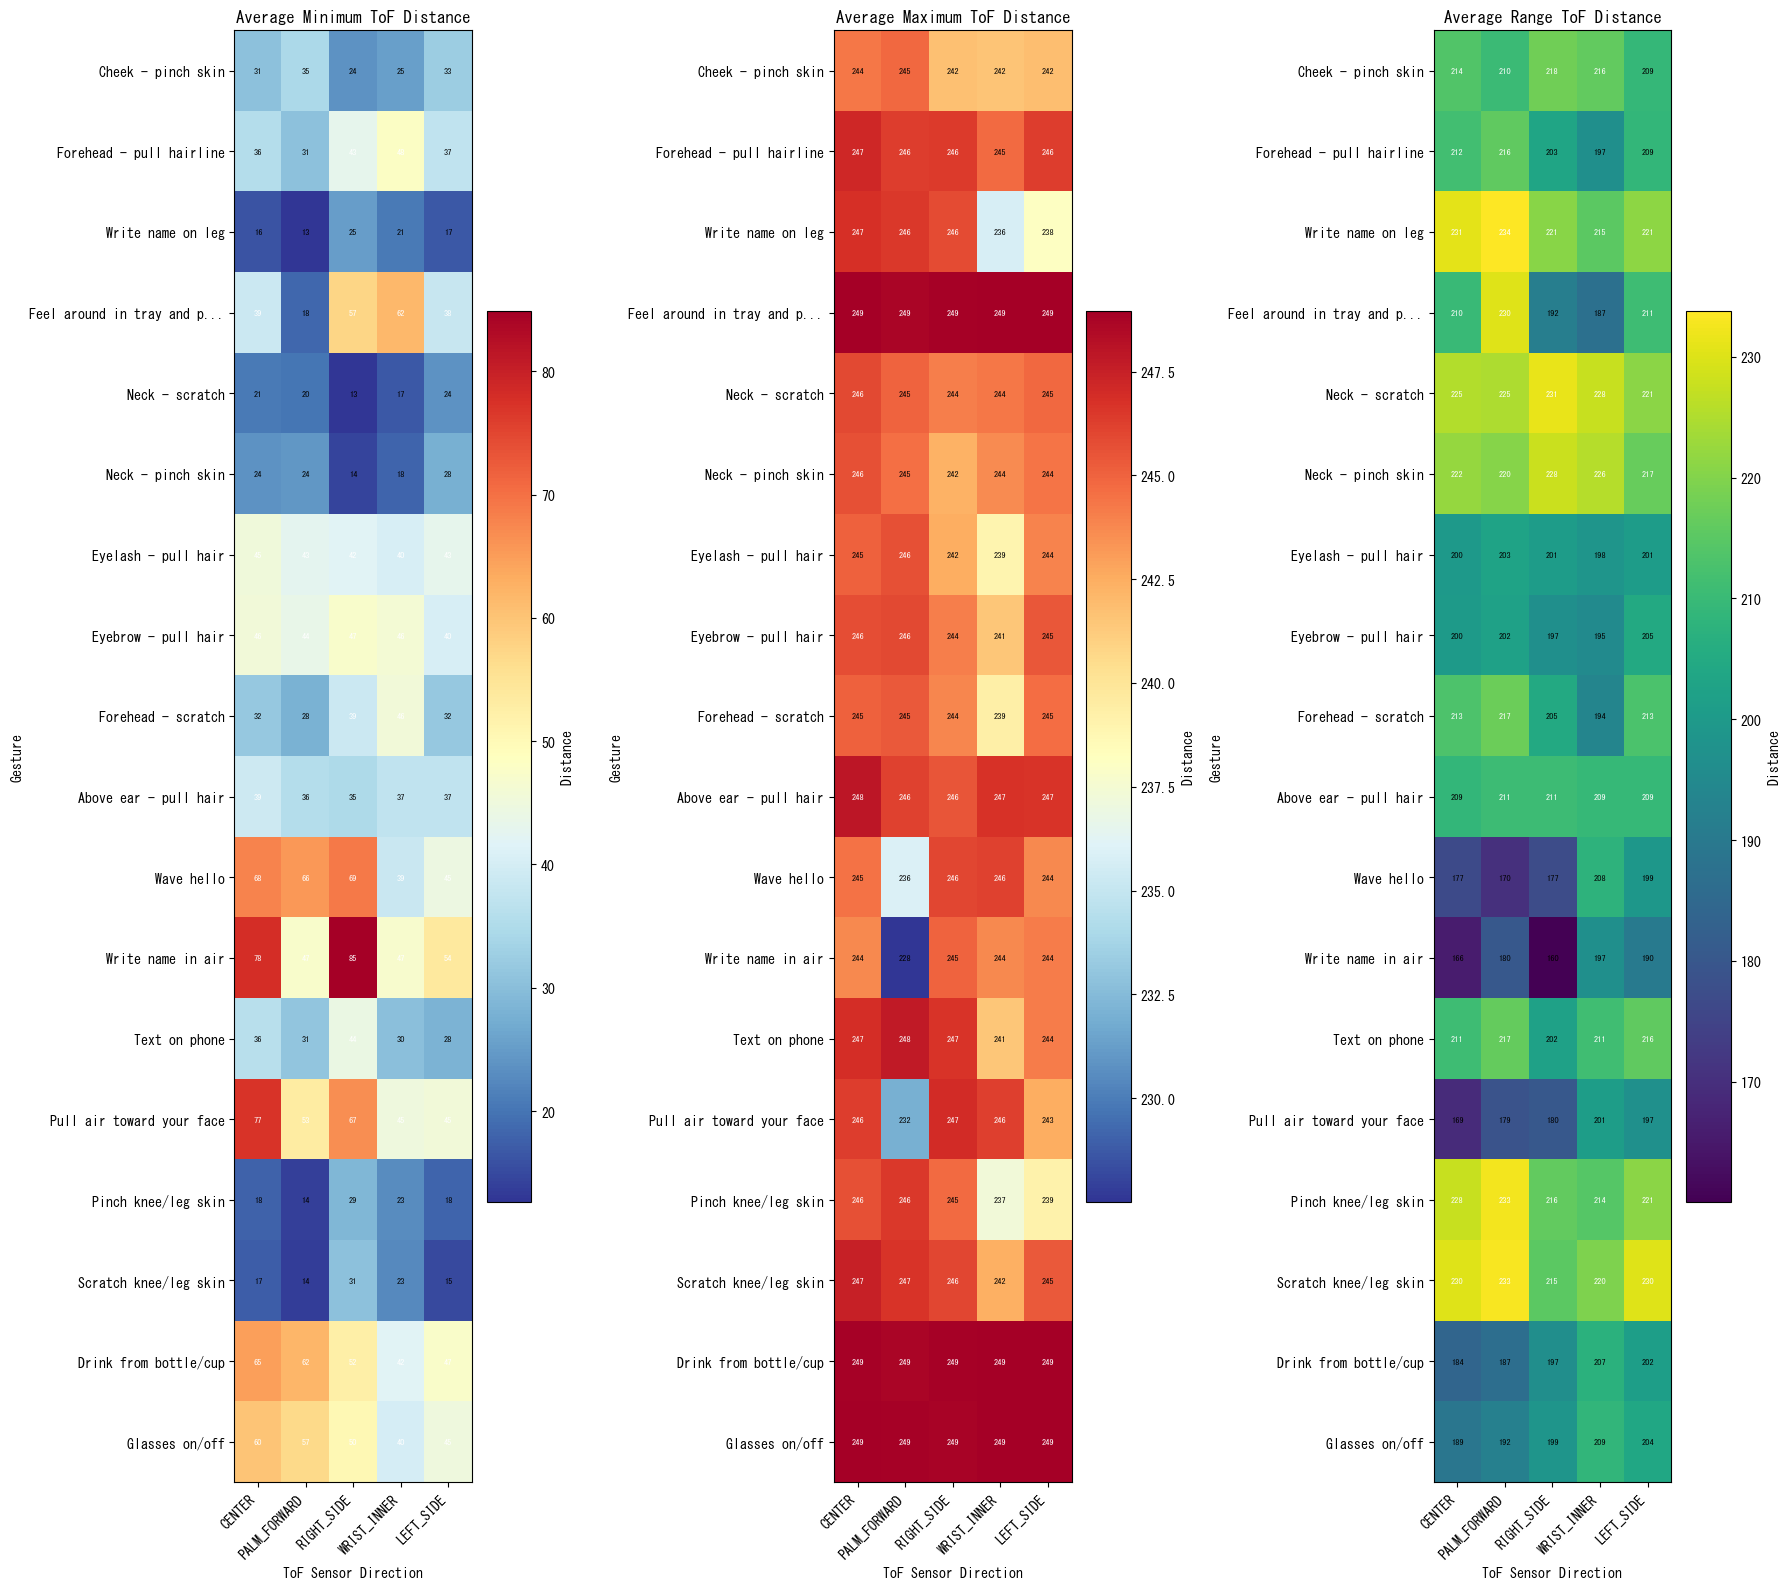

In [81]:
def visualize_simple_sensor_heatmaps(gesture_sensor_summary):
    """
    シンプルな自動設定ヒートマップ（matplotlib任せ）
    """
    
    # ヒートマップ用データ準備
    gestures = list(gesture_sensor_summary.keys())
    sensors = ['tof_1', 'tof_2', 'tof_3', 'tof_4', 'tof_5']
    sensor_labels = ['CENTER', 'PALM_FORWARD', 'RIGHT_SIDE', 'WRIST_INNER', 'LEFT_SIDE']
    
    # 各統計量のマトリックス作成
    def create_heatmap_matrix(stat_key):
        heatmap_data = []
        for gesture in gestures:
            gesture_row = []
            for sensor in sensors:
                if sensor in gesture_sensor_summary[gesture]:
                    value = gesture_sensor_summary[gesture][sensor][stat_key]
                    gesture_row.append(value)
                else:
                    gesture_row.append(np.nan)
            heatmap_data.append(gesture_row)
        return np.array(heatmap_data)
    
    # 3つの統計量のマトリックス作成
    min_matrix = create_heatmap_matrix('avg_min')
    max_matrix = create_heatmap_matrix('avg_max')
    range_matrix = create_heatmap_matrix('avg_range')
    
    # サブプロット作成
    fig, axes = plt.subplots(1, 3, figsize=(18, 16))
    
    # 統計量設定（範囲は自動）
    stat_configs = [
        {
            'data': min_matrix,
            'title': 'Average Minimum ToF Distance',
            'ax': axes[0],
            'cmap': 'RdYlBu_r'
        },
        {
            'data': max_matrix,
            'title': 'Average Maximum ToF Distance',
            'ax': axes[1],
            'cmap': 'RdYlBu_r'
        },
        {
            'data': range_matrix,
            'title': 'Average Range ToF Distance',
            'ax': axes[2],
            'cmap': 'viridis'
        }
    ]
    
    for config in stat_configs:
        ax = config['ax']
        data = config['data']
        
        # ヒートマップ作成（範囲は自動設定）
        im = ax.imshow(data, cmap=config['cmap'], aspect='auto')
        
        # 軸設定
        ax.set_xticks(range(len(sensors)))
        ax.set_xticklabels(sensor_labels, rotation=45, ha='right')
        ax.set_yticks(range(len(gestures)))
        ax.set_yticklabels([g[:25] + '...' if len(g) > 25 else g for g in gestures])
        
        ax.set_xlabel('ToF Sensor Direction')
        ax.set_ylabel('Gesture')
        ax.set_title(config['title'])
        
        # カラーバー
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Distance')
        
        # 数値表示（自動範囲での中央値を閾値に）
        valid_data = data[~np.isnan(data)]
        if len(valid_data) > 0:
            threshold = np.median(valid_data)
            for i in range(len(gestures)):
                for j in range(len(sensors)):
                    if not np.isnan(data[i, j]):
                        color = 'white' if data[i, j] > threshold else 'black'
                        ax.text(j, i, f'{data[i, j]:.0f}',
                               ha="center", va="center", color=color, fontsize=6)
    
    plt.tight_layout()
    plt.show()

# シンプル版実行
visualize_simple_sensor_heatmaps(gesture_sensor_summary)

=== TOF_1センサー min/max分布 箱ひげ図 ===


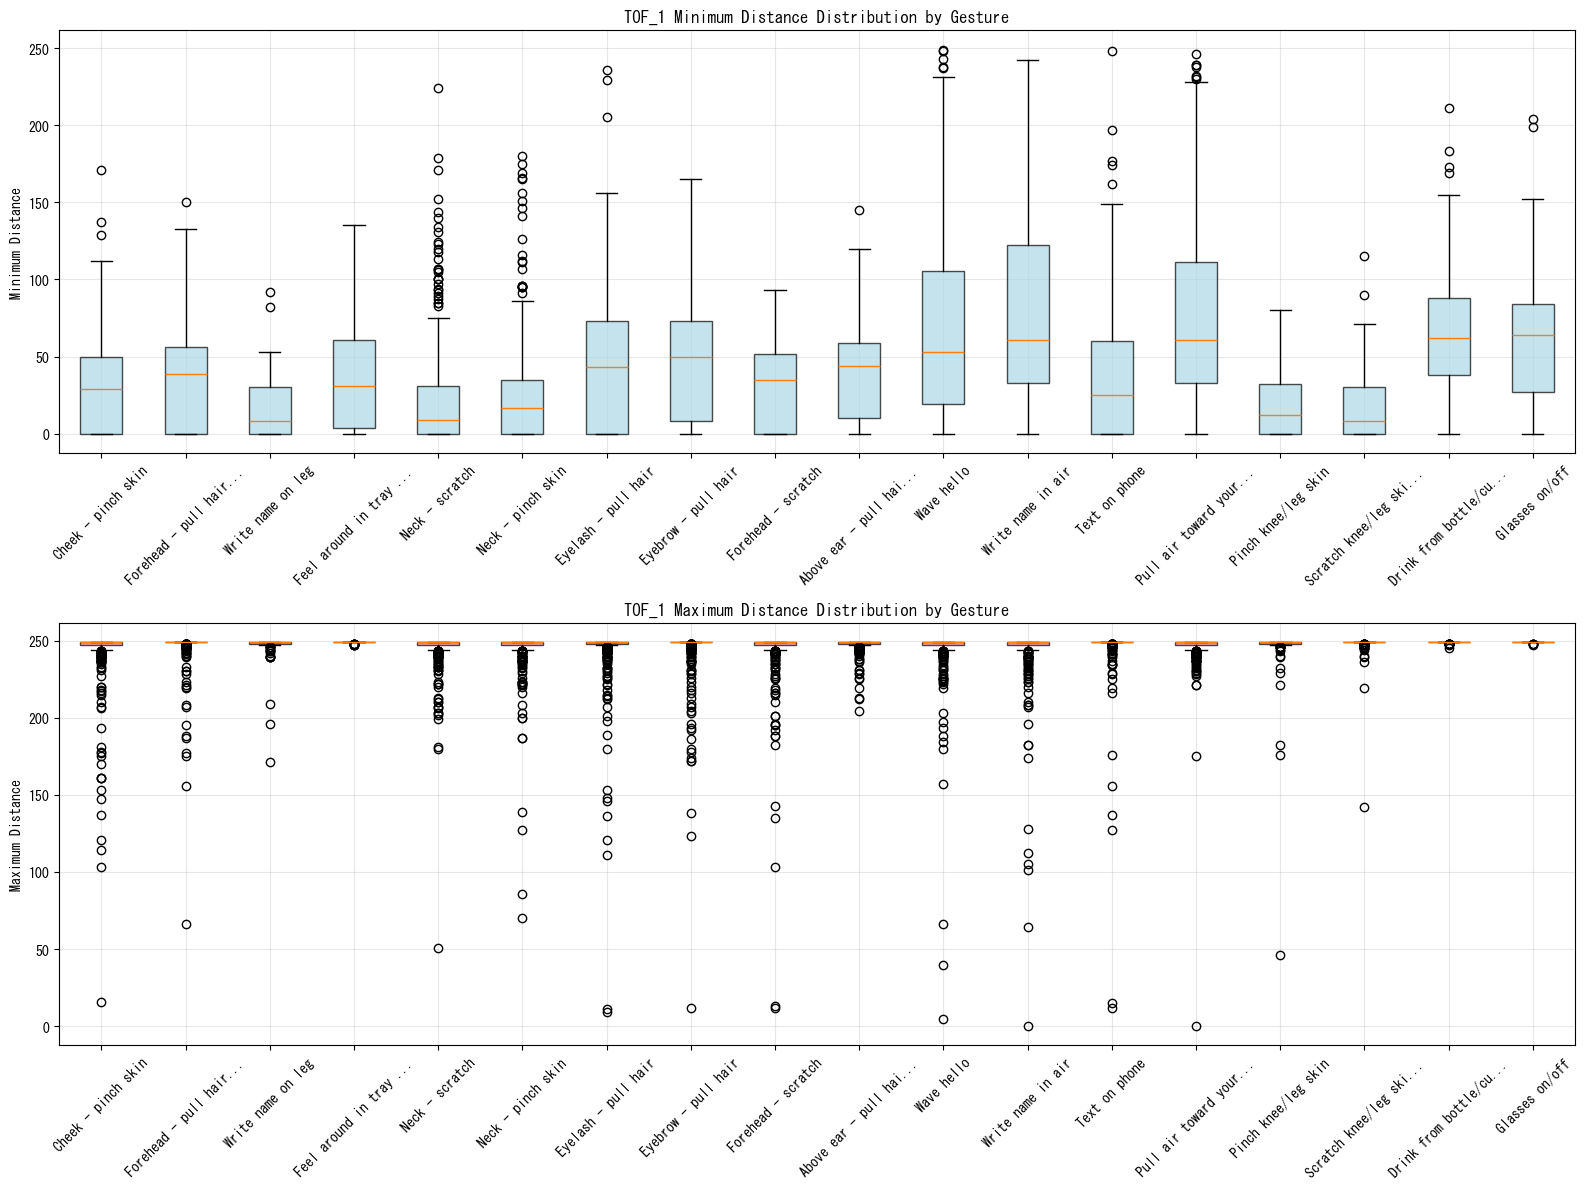


📊 TOF_1 統計サマリー:
Gesture                             Min_Median Min_IQR      Max_Median Max_IQR     
-------------------------------------------------------------------------------------
Cheek - pinch skin                  29.0       50.0         249.0      2.0         
Forehead - pull hairline            39.0       56.0         249.0      0.0         
Write name on leg                   8.0        30.0         249.0      1.0         
Feel around in tray and pull out    31.0       57.0         249.0      0.0         
Neck - scratch                      9.0        31.0         249.0      2.0         
Neck - pinch skin                   17.0       35.0         249.0      2.0         
Eyelash - pull hair                 43.0       73.0         249.0      1.0         
Eyebrow - pull hair                 50.0       65.0         249.0      0.0         
Forehead - scratch                  35.0       52.0         249.0      2.0         
Above ear - pull hair               44.0       49.0      

In [82]:
def visualize_tof1_boxplots(gesture_sensor_stats):
    """
    TOF_1センサーのmin/max分布を箱ひげ図で可視化
    """
    
    print("=== TOF_1センサー min/max分布 箱ひげ図 ===")
    
    # TOF_1のmin/maxデータを収集
    gesture_min_data = {}
    gesture_max_data = {}
    gesture_names = []
    
    for gesture, sequences in gesture_sensor_stats.items():
        if len(sequences) >= 3:  # 十分なシーケンス数がある場合のみ
            tof1_mins = []
            tof1_maxs = []
            
            for seq_id, sensor_data in sequences.items():
                if 'tof_1' in sensor_data and not np.isnan(sensor_data['tof_1']['min']):
                    tof1_mins.append(sensor_data['tof_1']['min'])
                    tof1_maxs.append(sensor_data['tof_1']['max'])
            
            if len(tof1_mins) >= 3:  # 最低3シーケンス
                gesture_min_data[gesture] = tof1_mins
                gesture_max_data[gesture] = tof1_maxs
                gesture_names.append(gesture)
    
    # 2つのサブプロット（min, max）
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    
    # Min値の箱ひげ図
    ax1 = axes[0]
    min_data_list = [gesture_min_data[gesture] for gesture in gesture_names]
    bp1 = ax1.boxplot(min_data_list, labels=[g[:20] + '...' if len(g) > 20 else g for g in gesture_names], 
                      patch_artist=True)
    
    # Min値の箱ひげ図の装飾
    for patch in bp1['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    
    ax1.set_title('TOF_1 Minimum Distance Distribution by Gesture')
    ax1.set_ylabel('Minimum Distance')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # Max値の箱ひげ図
    ax2 = axes[1]
    max_data_list = [gesture_max_data[gesture] for gesture in gesture_names]
    bp2 = ax2.boxplot(max_data_list, labels=[g[:20] + '...' if len(g) > 20 else g for g in gesture_names], 
                      patch_artist=True)
    
    # Max値の箱ひげ図の装飾
    for patch in bp2['boxes']:
        patch.set_facecolor('lightcoral')
        patch.set_alpha(0.7)
    
    ax2.set_title('TOF_1 Maximum Distance Distribution by Gesture')
    ax2.set_ylabel('Maximum Distance')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 統計サマリー表示
    print(f"\n📊 TOF_1 統計サマリー:")
    print(f"{'Gesture':<35} {'Min_Median':<10} {'Min_IQR':<12} {'Max_Median':<10} {'Max_IQR':<12}")
    print("-" * 85)
    
    for gesture in gesture_names[:10]:  # 上位10個表示
        mins = gesture_min_data[gesture]
        maxs = gesture_max_data[gesture]
        
        min_median = np.median(mins)
        min_iqr = np.percentile(mins, 75) - np.percentile(mins, 25)
        max_median = np.median(maxs)
        max_iqr = np.percentile(maxs, 75) - np.percentile(maxs, 25)
        
        print(f"{gesture[:33]:<35} {min_median:<10.1f} {min_iqr:<12.1f} {max_median:<10.1f} {max_iqr:<12.1f}")

# TOF_1箱ひげ図実行
visualize_tof1_boxplots(gesture_sensor_stats)

## Improve ToF Features

In [14]:
def extract_tof_features(df, tof_cols) -> dict:
    """
    ToFセンサーの特徴量を抽出する関数
    各センサー（tof_1～tof_5）ごとに10個の特徴量を作成
    
    Parameters:
    -----------
    df : pandas.DataFrame
        データフレーム
    tof_cols : list
        ToF関連の列名リスト
        
    Returns:
    --------
    dict : ToF特徴量の辞書
    """
    feats = {}
    
    # 各ToFセンサー（1-5）ごとに特徴量を作成
    for sensor_id in range(1, 6):
        tof_sensor_cols = [col for col in tof_cols if col.startswith(f'tof_{sensor_id}_v')]
        
        if not tof_sensor_cols:
            continue
            
        # 有効性チェック
        sensor_data = df[tof_sensor_cols].values
        valid_sensor = sensor_data >= 0
        valid_ratio = np.mean(valid_sensor)
        
        # 有効データが少ない場合はデフォルト値を設定
        if valid_ratio < 0.1:
            # デフォルト値（10個）
            feats[f'tof_{sensor_id}_global_mean'] = 0
            feats[f'tof_{sensor_id}_global_std'] = 0
            feats[f'tof_{sensor_id}_valid_ratio'] = 0
            feats[f'tof_{sensor_id}_pixel_min_mean'] = 0
            feats[f'tof_{sensor_id}_pixel_median_mean'] = 0
            feats[f'tof_{sensor_id}_Prepare_mean'] = 0
            feats[f'tof_{sensor_id}_Moving_mean'] = 0
            feats[f'tof_{sensor_id}_At_Target_mean'] = 0
            feats[f'tof_{sensor_id}_Gesture_mean'] = 0
            feats[f'tof_{sensor_id}_gesture_variation'] = 0
            feats[f'tof_{sensor_id}_gesture_trend'] = 0
            feats[f'tof_{sensor_id}_gesture_instability'] = 0
            continue
        
        # 1. センサー全体統計（3特徴量）
        valid_sensor_values = sensor_data[valid_sensor]
        if len(valid_sensor_values) > 0:
            feats[f'tof_{sensor_id}_global_mean'] = np.mean(valid_sensor_values)
            feats[f'tof_{sensor_id}_global_std'] = np.std(valid_sensor_values)
            feats[f'tof_{sensor_id}_valid_ratio'] = valid_ratio

            pixel_mins = []
            pixel_medians = []
            for i in range(sensor_data.shape[1]):  # 各チャンネル
                pixel_data = sensor_data[:, i]
                valid_pixel_data = pixel_data[pixel_data >= 0]
                if len(valid_pixel_data) > 0:
                    pixel_mins.append(np.min(valid_pixel_data))
                    pixel_medians.append(np.median(valid_pixel_data))
            
            feats[f'tof_{sensor_id}_pixel_min_mean'] = np.mean(pixel_mins) if pixel_mins else 0
            feats[f'tof_{sensor_id}_pixel_median_mean'] = np.mean(pixel_medians) if pixel_medians else 0
        else:
            feats[f'tof_{sensor_id}_global_mean'] = 0
            feats[f'tof_{sensor_id}_global_std'] = 0
            feats[f'tof_{sensor_id}_valid_ratio'] = 0
            feats[f'tof_{sensor_id}_pixel_min_mean'] = 0
            feats[f'tof_{sensor_id}_pixel_median_mean'] = 0
        
        # 2. フェーズ別平均統計（4特徴量）
        phases = ['Prepare', 'Moving', 'At_Target', 'Gesture']
        behavior_map = {
            'Relaxes and moves hand to target location': 'Prepare',
            'Moves hand to target location': 'Moving',
            'Hand at target location': 'At_Target',
            'Performs gesture': 'Gesture'
        }
        
        for phase in phases:
            if 'behavior' in df.columns:
                phase_mask = df['behavior'].map(behavior_map) == phase
                if phase_mask.any():
                    phase_sensor_data = sensor_data[phase_mask]
                    phase_valid = phase_sensor_data >= 0
                    phase_valid_values = phase_sensor_data[phase_valid]
                    
                    if len(phase_valid_values) > 0:
                        feats[f'tof_{sensor_id}_{phase}_mean'] = np.mean(phase_valid_values)
                    else:
                        feats[f'tof_{sensor_id}_{phase}_mean'] = 0
                else:
                    feats[f'tof_{sensor_id}_{phase}_mean'] = 0
            else:
                feats[f'tof_{sensor_id}_{phase}_mean'] = 0
        
        # 3. Gestureフェーズの動的特徴（3特徴量）
        if 'behavior' in df.columns:
            gesture_mask = df['behavior'].map(behavior_map) == 'Gesture'
            if gesture_mask.any() and gesture_mask.sum() > 2:
                gesture_variations = []
                gesture_trends = []
                gesture_changes = []
                
                for col in tof_sensor_cols:
                    gesture_data = df.loc[gesture_mask, col]
                    valid_gesture_data = gesture_data[gesture_data >= 0]
                    
                    if len(valid_gesture_data) > 2:
                        # 変動性
                        gesture_variations.append(np.std(valid_gesture_data))
                        
                        # トレンド（傾き）
                        x_vals = np.arange(len(valid_gesture_data))
                        if len(x_vals) > 1:
                            trend = np.polyfit(x_vals, valid_gesture_data.values, 1)[0]
                            gesture_trends.append(trend)
                        
                        # 急激な変化の割合
                        if len(valid_gesture_data) > 1:
                            diff_data = np.diff(valid_gesture_data.values)
                            if len(diff_data) > 0 and np.std(diff_data) > 0:
                                threshold = np.std(diff_data) * 1.5
                                sharp_changes = np.sum(np.abs(diff_data) > threshold) / len(diff_data)
                                gesture_changes.append(sharp_changes)
                
                # 平均値を特徴量として使用
                feats[f'tof_{sensor_id}_gesture_variation'] = np.mean(gesture_variations) if gesture_variations else 0
                feats[f'tof_{sensor_id}_gesture_trend'] = np.mean(gesture_trends) if gesture_trends else 0
                feats[f'tof_{sensor_id}_gesture_instability'] = np.mean(gesture_changes) if gesture_changes else 0
            else:
                feats[f'tof_{sensor_id}_gesture_variation'] = 0
                feats[f'tof_{sensor_id}_gesture_trend'] = 0
                feats[f'tof_{sensor_id}_gesture_instability'] = 0
        else:
            feats[f'tof_{sensor_id}_gesture_variation'] = 0
            feats[f'tof_{sensor_id}_gesture_trend'] = 0
            feats[f'tof_{sensor_id}_gesture_instability'] = 0
    
    return feats

In [17]:
def feature_set_v04(df: pd.DataFrame, use_extra: bool = False) -> dict:
    """
    Extracts an enhanced set of features from sensor data for gesture prediction.
    """
    feats = {}
    imu_cols = [c for c in df.columns if any(x in c for x in ['acc_', 'rot_'])]

    # Vector magnitudes and jerk features
    df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
    df['rot_mag'] = np.sqrt(df['rot_x']**2 + df['rot_y']**2 + df['rot_z']**2)
    df['acc_jerk_x'] = df['acc_x'].diff().fillna(0)
    df['acc_jerk_y'] = df['acc_y'].diff().fillna(0)
    df['acc_jerk_z'] = df['acc_z'].diff().fillna(0)
    imu_cols.extend(['acc_mag', 'rot_mag', 'acc_jerk_x', 'acc_jerk_y', 'acc_jerk_z'])

    # Feature Extraction for IMU Sensors
    for col in imu_cols:
        arr = df[col].values

        # Basic Statistics
        feats[f'{col}_mean'] = np.mean(arr)
        feats[f'{col}_std'] = np.std(arr)
        feats[f'{col}_min'] = np.min(arr)
        feats[f'{col}_max'] = np.max(arr)

        # Rolling Window Features
        for window in [10, 20]:
            rolling_mean = df[col].rolling(window=window, min_periods=1).mean()
            feats[f'{col}_roll_mean_{window}_mean'] = rolling_mean.mean()

        # Frequency Domain Features (FFT)
        fft_vals = rfft(arr)
        fft_mags = np.abs(fft_vals)
        if len(fft_mags) > 1:
            feats[f'{col}_fft_max'] = np.max(fft_mags)

    # Cross-Sensor Correlations
    for (c1, c2) in [('acc_x', 'acc_y'), ('acc_x', 'acc_z'), ('acc_y', 'acc_z'),
                     ('rot_x', 'rot_y'), ('rot_x', 'rot_z'), ('rot_y', 'rot_z')]:
        if c1 in df.columns and c2 in df.columns:
            feats[f'{c1}_{c2}_corr'] = np.corrcoef(df[c1], df[c2])[0, 1]

    # Extra Sensor Features (Thermal & ToF)
    if use_extra:
        thm_cols = [c for c in df.columns if 'thm' in c]
        tof_cols = [c for c in df.columns if 'tof' in c]
        
        # Thermal Features
        if thm_cols:
            thm_data = df[thm_cols].values
            feats['thm_max_across_sensors'] = np.nanmax(thm_data, axis=1).mean()
            feats['thm_std_across_sensors'] = np.nanstd(thm_data, axis=1).mean()
            for col in thm_cols:
                feats[f'{col}_mean'] = np.nanmean(df[col])
                feats[f'{col}_max'] = np.nanmax(df[col])

        # ToF
        if tof_cols:
            tof_features = extract_tof_features(df, tof_cols)
            feats.update(tof_features)

    return feats

In [16]:
def build_features_v04(data: pd.DataFrame, demographics: pd.DataFrame, use_extra: bool) -> tuple[pd.DataFrame, list]:
    """Builds feature matrix and returns features with subject groups for CV."""
    features = []
    groups = []
    for seq_id, g in data.groupby('sequence_id'):
        subj = g['subject'].iloc[0]
        groups.append(subj)
        feats = feature_set_v04(g, use_extra=use_extra)
        feats['sequence_id'] = seq_id
        demo_row = demographics[demographics['subject'] == subj]
        if not demo_row.empty:
            demo = demo_row.iloc[0]
            for dcol in ['age', 'sex', 'height_cm', 'handedness']:
                feats[dcol] = demo.get(dcol, np.nan)
        features.append(feats)
    df_feats = pd.DataFrame(features).set_index('sequence_id')
    if 'sex' in df_feats.columns:
        df_feats['sex'] = df_feats['sex'].map({'M': 1, 'F': 0})
    if 'handedness' in df_feats.columns:
        df_feats['handedness'] = df_feats['handedness'].map({'R': 1, 'L': 0, 'A': 2})
    
    return df_feats, groups

In [18]:
def create_balanced_feature_datasets_v04(train_balanced, train_d):
    """
    軽量化されたデータから特徴量セットを作成
    """
    print("=== 軽量化特徴量セット作成 ===")
    
    # IMU-only用データ作成
    train_imu_balanced = train_balanced.copy()
    train_imu_balanced[thm_cols + tof_cols] = np.nan
    
    # Full-sensor用データ作成（元々full-sensorがあるシーケンスのみ）
    full_sensor_sequences = train_balanced[
        ~train_balanced['sequence_id'].isin(imu_only_seq_ids)
    ]['sequence_id'].unique()
    
    print(f"IMU-only対象: {len(train_imu_balanced['sequence_id'].unique())} sequences")
    print(f"Full-sensor対象: {len(full_sensor_sequences)} sequences")
    
    # 特徴量構築
    print("IMU-only特徴量構築中...")
    X_imu_balanced, groups_imu_balanced = build_features_v04(
        train_imu_balanced, train_d, use_extra=False
    )
    y_imu_balanced = train_imu_balanced.groupby('sequence_id')['e_gesture'].first().loc[X_imu_balanced.index]
    
    print("Full-sensor特徴量構築中...")
    X_full_balanced, groups_full_balanced = build_features_v04(
        train_balanced[train_balanced['sequence_id'].isin(full_sensor_sequences)], 
        train_d, use_extra=True
    )
    y_full_balanced = train_balanced.groupby('sequence_id')['e_gesture'].first().loc[X_full_balanced.index]
    
    print(f"\n=== 特徴量セット完成 ===")
    print(f"IMU-only: {X_imu_balanced.shape} (samples × features)")
    print(f"Full-sensor: {X_full_balanced.shape} (samples × features)")
    
    return (X_imu_balanced, y_imu_balanced, groups_imu_balanced, 
            X_full_balanced, y_full_balanced, groups_full_balanced)

# Training model

In [21]:
def balanced_cv_confusion_matrix_with_model(model, X, y, groups, model_name, gesture_names, n_folds=3):
    """
    バランス軽量化データでのCV混同行列作成 + 最終学習済みモデル返却
    """
    print(f"=== {model_name} バランスCV混同行列 (n_folds={n_folds}) ===")
    print(f"データサイズ: {X.shape}")
    print(f"被験者グループ数: {len(set(groups))}")
    
    all_true = []
    all_pred = []
    fold_results = []
    
    start_time = time.time()
    
    # ===== CV実行 =====
    for fold, (train_idx, val_idx) in enumerate(GroupKFold(n_splits=n_folds).split(X, y, groups)):
        fold_start = time.time()
        
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        print(f"Fold {fold+1}: Train={len(X_train)}, Val={len(X_val)}")
        
        # モデル学習
        fold_model = clone(model)
        fold_model.fit(X_train, y_train)
        
        # 予測
        y_pred = fold_model.predict(X_val)
        
        # 結果保存
        all_true.extend(y_val.values)
        all_pred.extend(y_pred)
        
        # フォールド結果
        fold_acc = (y_pred == y_val).mean()
        fold_f1 = f1_score(y_val, y_pred, average='macro')
        fold_time = time.time() - fold_start
        
        fold_results.append({
            'fold': fold + 1,
            'accuracy': fold_acc,
            'f1_macro': fold_f1,
            'time': fold_time
        })
        
        print(f"  Accuracy: {fold_acc:.3f}, F1-macro: {fold_f1:.3f}, Time: {fold_time:.1f}s")
    
    total_time = time.time() - start_time
    
    # ===== CV結果表示 =====
    overall_accuracy = (np.array(all_true) == np.array(all_pred)).mean()
    overall_f1 = f1_score(all_true, all_pred, average='macro')
    
    print(f"\n=== CV結果 ===")
    print(f"CV精度: {overall_accuracy:.3f}")
    print(f"CV F1-macro: {overall_f1:.3f}")
    print(f"CV実行時間: {total_time:.1f}s")
    
    # ===== 最終モデル学習 =====
    print(f"\n=== 最終モデル学習 ===")
    final_model_start = time.time()
    
    # 全データで最終モデルを学習
    final_model = clone(model)
    final_model.fit(X, y)
    
    final_model_time = time.time() - final_model_start
    print(f"最終モデル学習時間: {final_model_time:.1f}s")
    print(f"学習データサイズ: {X.shape}")
    
    # ===== 混同行列作成・表示 =====
    cm = confusion_matrix(all_true, all_pred)
    
    plt.figure(figsize=(14, 11))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=gesture_names, yticklabels=gesture_names)
    plt.title(f'Balanced CV Confusion Matrix - {model_name}\n'
              f'CV Accuracy: {overall_accuracy:.3f}, CV F1-macro: {overall_f1:.3f}')
    plt.xlabel('Predicted Gesture')
    plt.ylabel('True Gesture')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # ===== 結果まとめ =====
    results_summary = {
        'cv_accuracy': overall_accuracy,
        'cv_f1_macro': overall_f1,
        'cv_time': total_time,
        'final_model_time': final_model_time,
        'fold_results': fold_results
    }
    
    print(f"\n=== 完了 ===")
    print(f"総実行時間: {total_time + final_model_time:.1f}s")
    
    return cm, all_true, all_pred, final_model, results_summary

## LightGBM (gbdt)

In [22]:
def create_lightweight_model_for_analysis(use_gpu=True):
    """
    特徴量重要度分析用の軽量化モデル作成
    """
    base_params = {
        'objective': 'multiclass',
        'metric': 'multi_logloss',
        'boosting_type': 'gbdt',
        'n_estimators': 100,  # 重要度分析用に軽量化
        'learning_rate': 0.1,
        'feature_fraction': 1.0,  # 全特徴量使用
        'bagging_fraction': 0.8,
        'num_leaves': 31,
        'random_state': CFG.seed,
        'verbose': -1,
        'importance_type': 'gain'  # 重要度計算方法指定
    }
    
    if use_gpu:
        base_params.update({
            'device': 'gpu',
            'gpu_platform_id': 0,
            'gpu_device_id': 0
        })
    else:
        base_params['device'] = 'cpu'
    
    return LGBMClassifier(**base_params)

In [22]:
analysis_imu_model = create_lightweight_model_for_analysis()
analysis_full_model = create_lightweight_model_for_analysis()

=== IMU-only モデル 学習・分析 ===
=== Lightweight IMU-only LightGBM バランスCV混同行列 (n_folds=3) ===
データサイズ: (1800, 370)
被験者グループ数: 81
Fold 1: Train=1197, Val=603
  Accuracy: 0.531, F1-macro: 0.522, Time: 13.9s
Fold 2: Train=1198, Val=602
  Accuracy: 0.497, F1-macro: 0.494, Time: 14.1s
Fold 3: Train=1205, Val=595
  Accuracy: 0.504, F1-macro: 0.488, Time: 14.1s

=== CV結果 ===
CV精度: 0.511
CV F1-macro: 0.502
CV実行時間: 42.1s

=== 最終モデル学習 ===
最終モデル学習時間: 15.5s
学習データサイズ: (1800, 370)


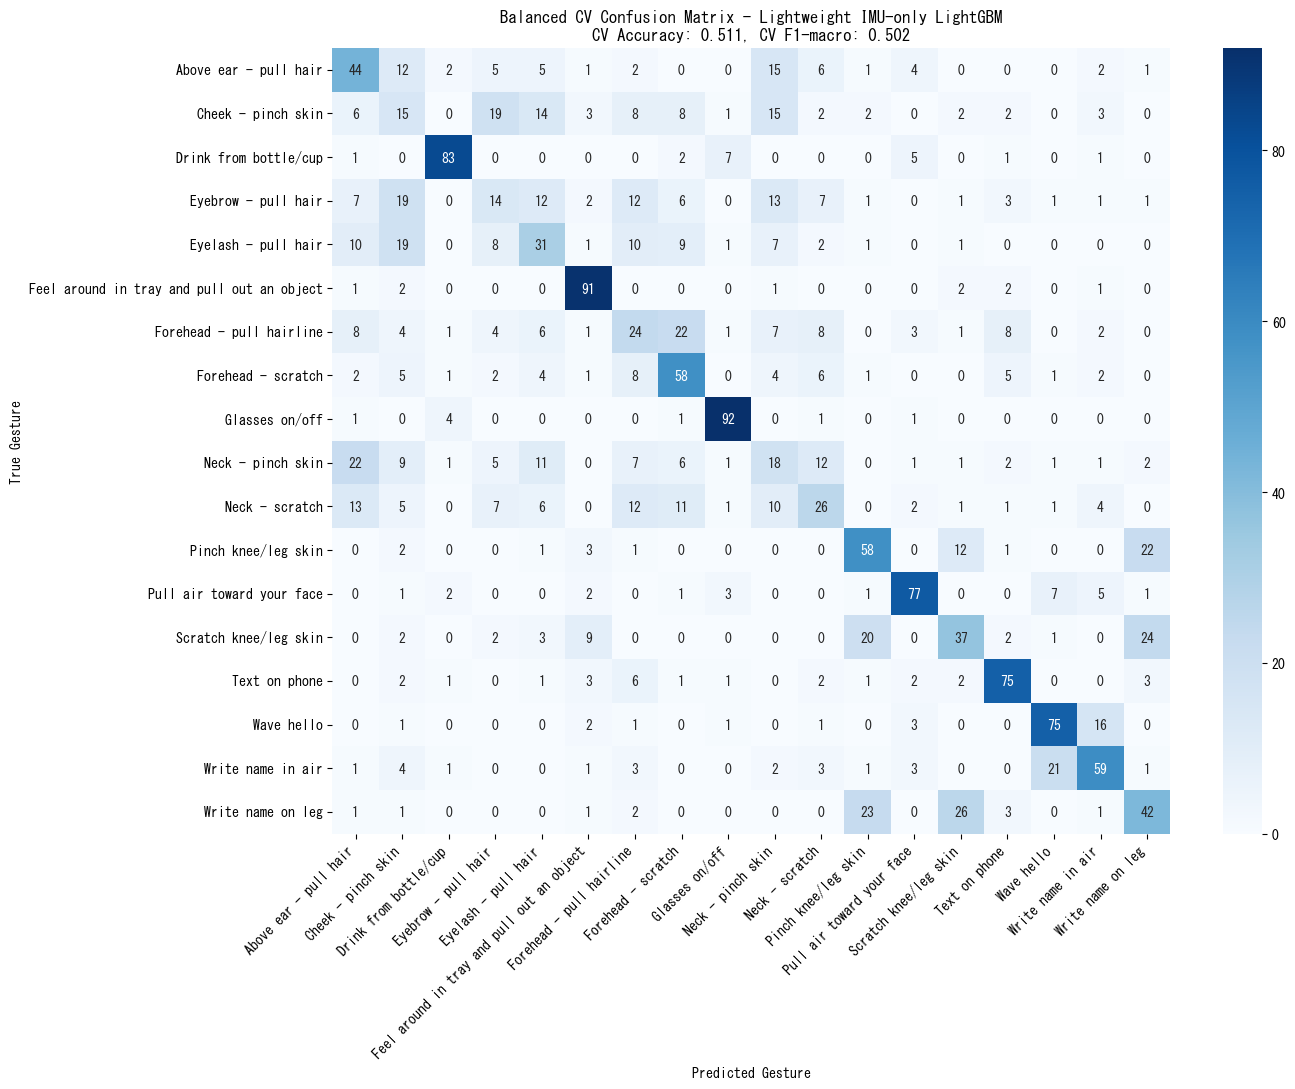


=== 完了 ===
総実行時間: 57.6s


In [23]:
print("=== IMU-only モデル 学習・分析 ===")
(cm_imu_bal, y_true_imu_bal, y_pred_imu_bal, 
 trained_imu_model, imu_results) = balanced_cv_confusion_matrix_with_model(
    analysis_imu_model, X_imu_bal, y_imu_bal, groups_imu_bal, 
    "Lightweight IMU-only LightGBM", le_gesture.classes_, n_folds=CFG.n_folds
)

=== Full-sensor モデル 学習・分析 ===
=== Lightweight Full-sensor LightGBM バランスCV混同行列 (n_folds=3) ===
データサイズ: (1681, 1349)
被験者グループ数: 79
Fold 1: Train=1122, Val=559
  Accuracy: 0.581, F1-macro: 0.581, Time: 31.9s
Fold 2: Train=1118, Val=563
  Accuracy: 0.577, F1-macro: 0.576, Time: 32.4s
Fold 3: Train=1122, Val=559
  Accuracy: 0.555, F1-macro: 0.531, Time: 32.2s

=== CV結果 ===
CV精度: 0.571
CV F1-macro: 0.565
CV実行時間: 96.5s

=== 最終モデル学習 ===
最終モデル学習時間: 36.2s
学習データサイズ: (1681, 1349)


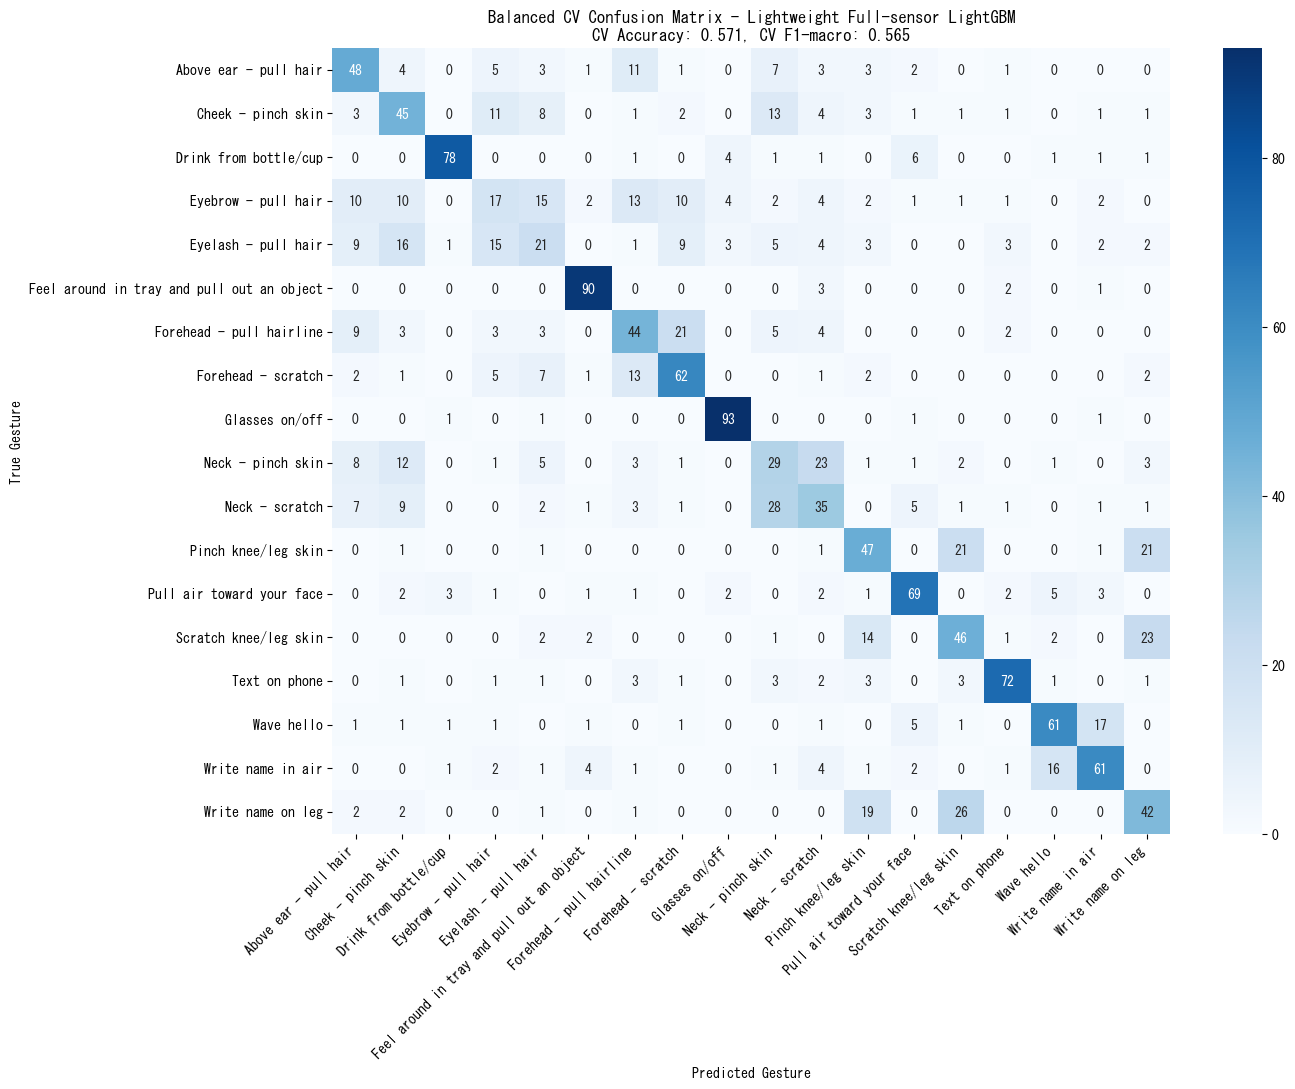


=== 完了 ===
総実行時間: 132.7s


In [24]:
print("=== Full-sensor モデル 学習・分析 ===")
(cm_full_bal, y_true_full_bal, y_pred_full_bal, 
 trained_full_model, full_results) = balanced_cv_confusion_matrix_with_model(
    analysis_full_model, X_full_bal, y_full_bal, groups_full_bal, 
    "Lightweight Full-sensor LightGBM", le_gesture.classes_, n_folds=CFG.n_folds
)

# Feature Reduction

In [25]:
# IMU-onlyモデルの特徴量重要度
imu_importances = trained_imu_model.feature_importances_
imu_feature_names = X_imu_bal.columns.tolist()

# Full-sensorモデルの特徴量重要度  
full_importances = trained_full_model.feature_importances_
full_feature_names = X_full_bal.columns.tolist()

print(f"IMU-only特徴量数: {len(imu_feature_names)}")
print(f"Full-sensor特徴量数: {len(full_feature_names)}")

IMU-only特徴量数: 370
Full-sensor特徴量数: 1349


In [26]:
def classify_sensor_type(feature_name):
    if any(sensor in feature_name for sensor in ['acc_', 'rot_']):
        return 'IMU'
    elif 'thm_' in feature_name:
        return 'Thermal'
    elif 'tof_' in feature_name:
        return 'ToF'
    elif feature_name in ['age', 'sex', 'height_cm', 'handedness']:
        return 'Demographics'
    else:
        return 'Other'

In [27]:

imu_importance_df = pd.DataFrame({
    'feature': imu_feature_names,
    'importance': imu_importances
}).sort_values('importance', ascending=False)

full_importance_df = pd.DataFrame({
    'feature': full_feature_names,
    'importance': full_importances
}).sort_values('importance', ascending=False)

imu_importance_df['sensor_type'] = imu_importance_df['feature'].apply(classify_sensor_type)
full_importance_df['sensor_type'] = full_importance_df['feature'].apply(classify_sensor_type)

In [28]:
def visualize_feature_importance_overview(importance_df, model_name):
    """
    特徴量重要度の全体的な可視化
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{model_name} - Feature Importance Analysis', fontsize=16)
    
    # 1. 上位30特徴量の棒グラフ
    ax1 = axes[0, 0]
    top_30 = importance_df.head(30)
    bars = ax1.barh(range(len(top_30)), top_30['importance'])
    ax1.set_yticks(range(len(top_30)))
    ax1.set_yticklabels(top_30['feature'], fontsize=8)
    ax1.set_xlabel('Feature Importance')
    ax1.set_title('Top 30 Features')
    ax1.invert_yaxis()
    
    # 2. 重要度分布ヒストグラム
    ax2 = axes[0, 1]
    ax2.hist(importance_df['importance'], bins=50, alpha=0.7, edgecolor='black')
    ax2.axvline(importance_df['importance'].mean(), color='red', linestyle='--', 
                label=f'Mean: {importance_df["importance"].mean():.4f}')
    ax2.set_xlabel('Feature Importance')
    ax2.set_ylabel('Count')
    ax2.set_title('Feature Importance Distribution')
    ax2.legend()
    
    # 3. センサータイプ別重要度
    ax3 = axes[1, 0]
    sensor_importance = importance_df.groupby('sensor_type')['importance'].agg(['sum', 'mean', 'count'])
    sensor_importance['sum'].plot(kind='bar', ax=ax3)
    ax3.set_title('Total Importance by Sensor Type')
    ax3.set_ylabel('Total Importance')
    ax3.tick_params(axis='x', rotation=45)
    
    # 4. 累積重要度
    ax4 = axes[1, 1]
    cumulative_importance = np.cumsum(importance_df['importance']) / importance_df['importance'].sum()
    ax4.plot(range(1, len(cumulative_importance) + 1), cumulative_importance)
    ax4.axhline(y=0.8, color='red', linestyle='--', label='80%')
    ax4.axhline(y=0.9, color='orange', linestyle='--', label='90%')
    ax4.axhline(y=0.95, color='green', linestyle='--', label='95%')
    ax4.set_xlabel('Number of Features')
    ax4.set_ylabel('Cumulative Importance')
    ax4.set_title('Cumulative Feature Importance')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return sensor_importance

IMU-only Model の可視化:


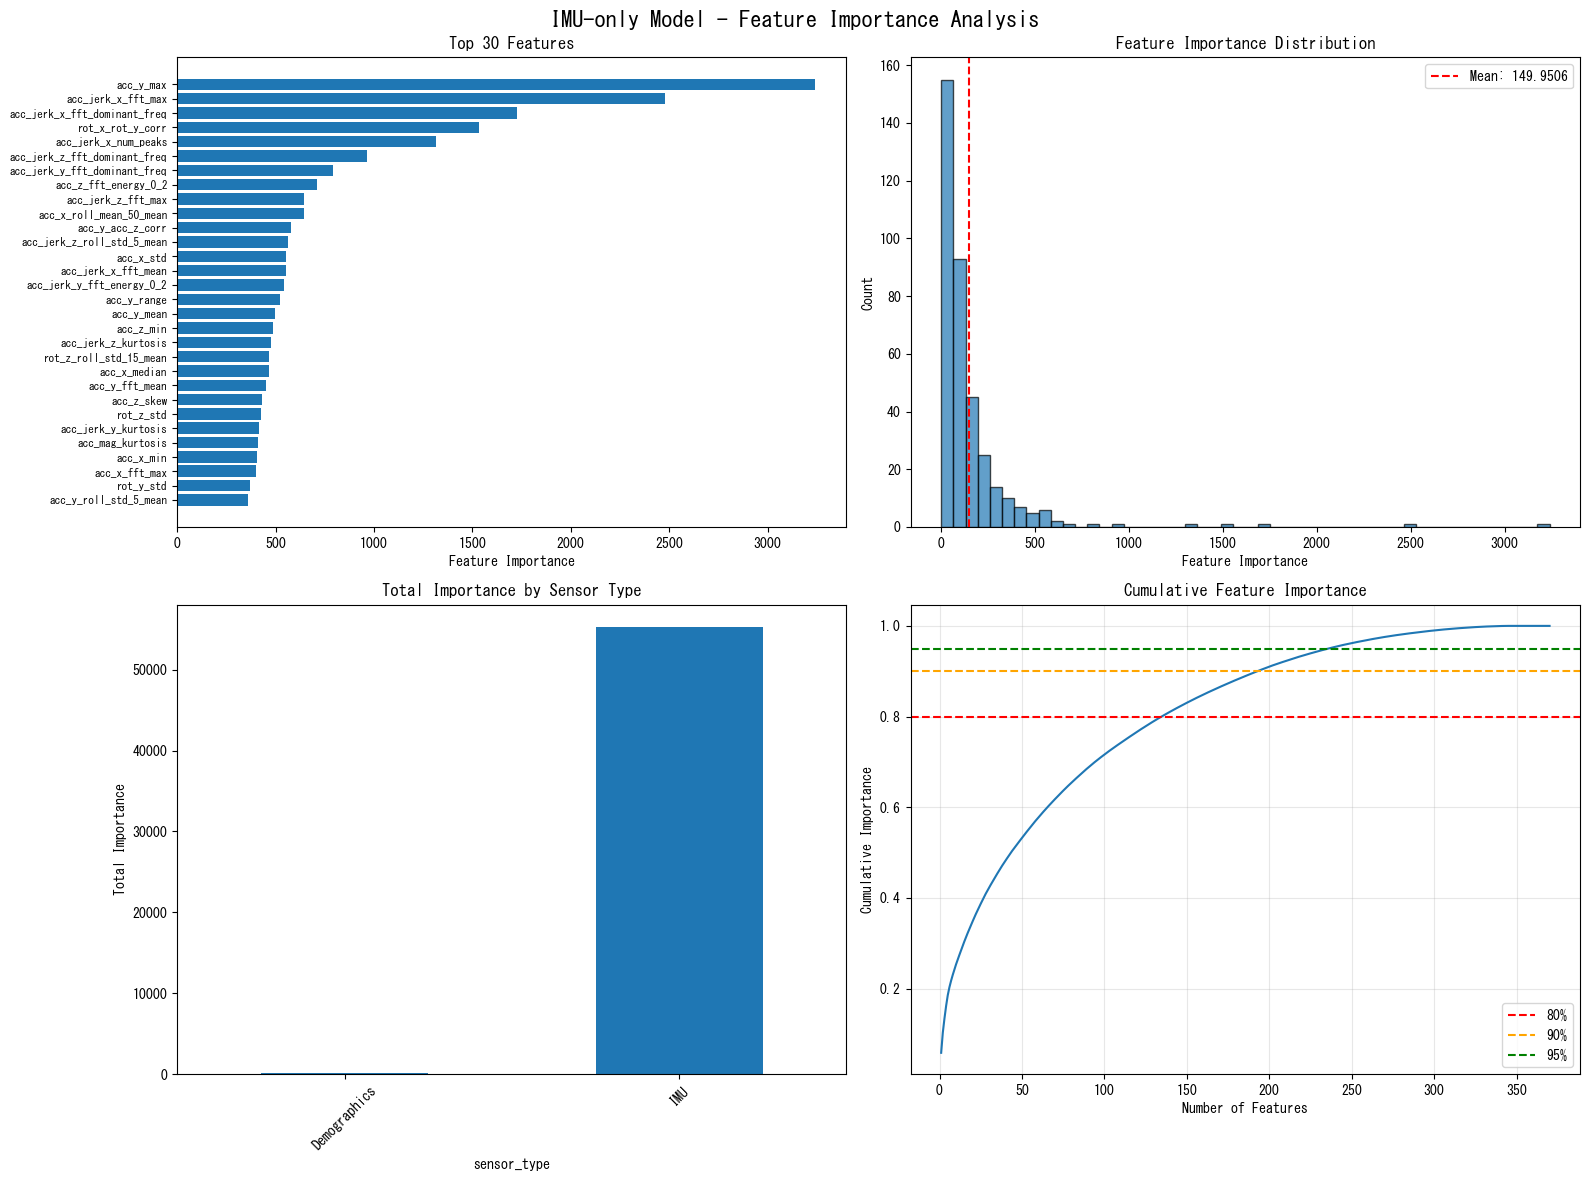


Full-sensor Model の可視化:


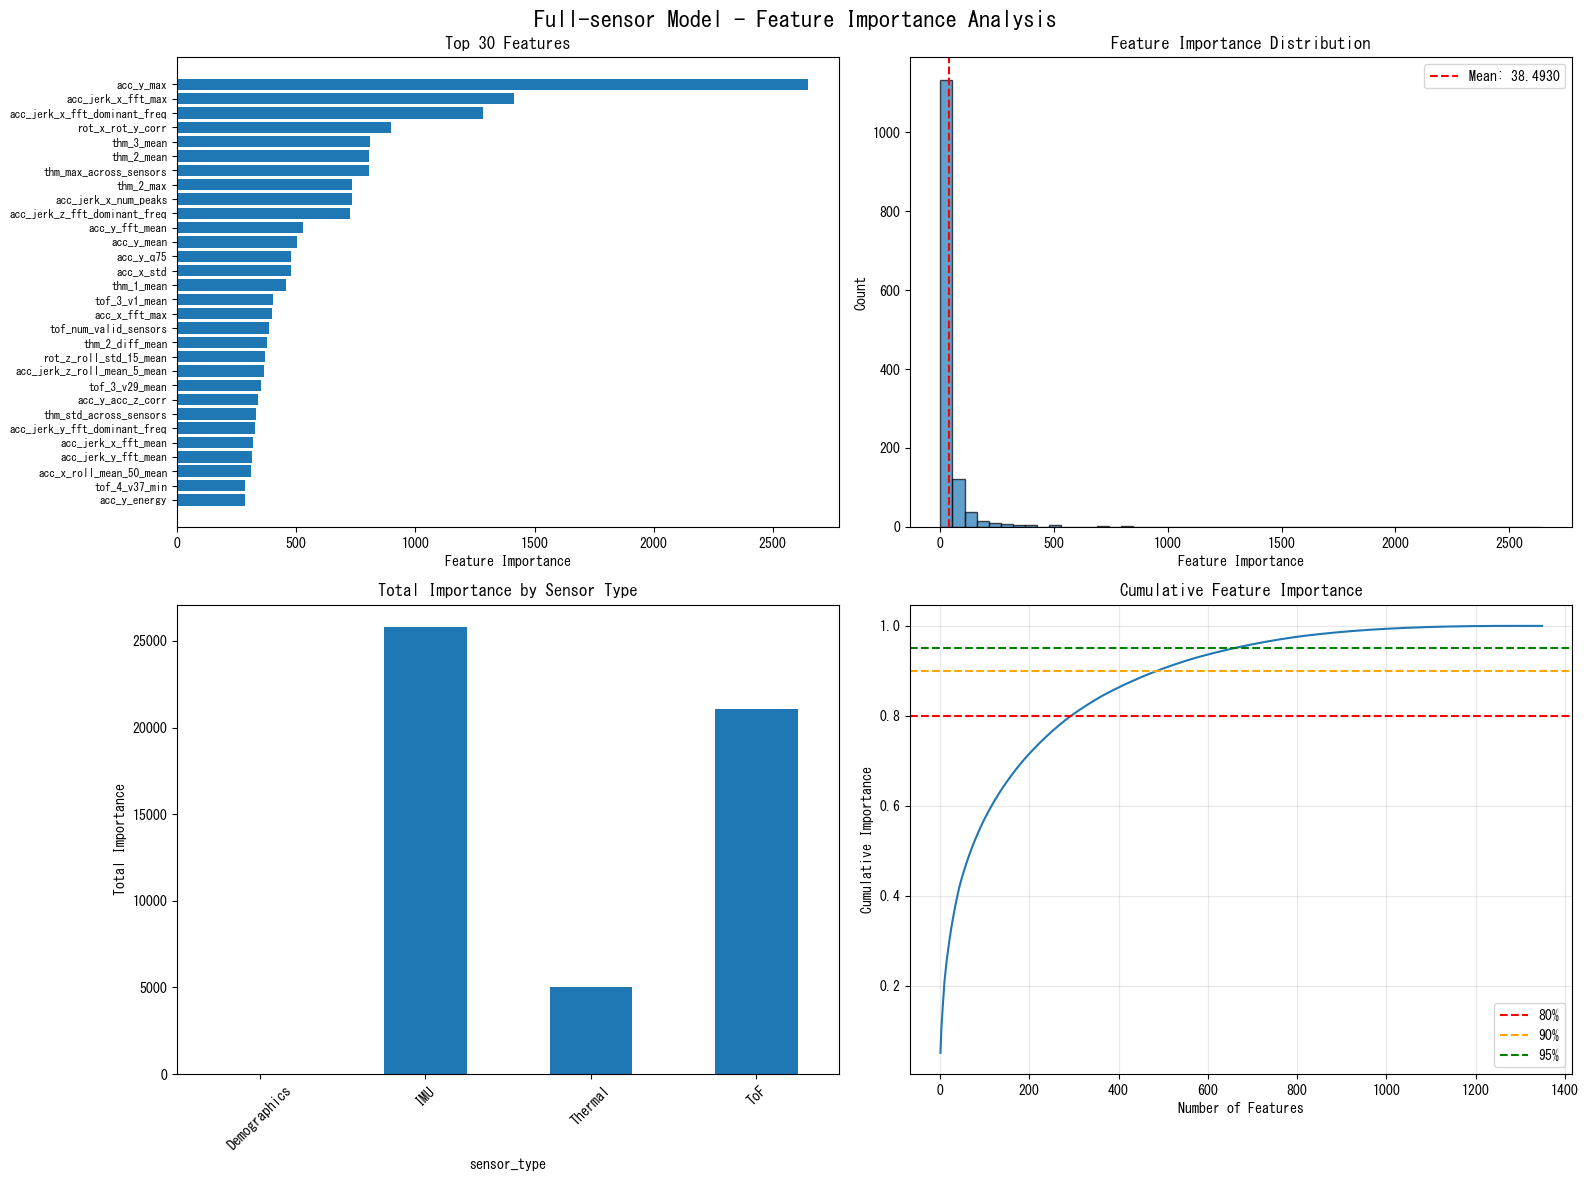

In [29]:
print("IMU-only Model の可視化:")
imu_sensor_importance = visualize_feature_importance_overview(imu_importance_df, "IMU-only Model")

print("\nFull-sensor Model の可視化:")
full_sensor_importance = visualize_feature_importance_overview(full_importance_df, "Full-sensor Model")

In [30]:
def analyze_sensor_type_contributions(importance_df, model_name):
    """
    センサータイプ別の詳細分析
    """
    print(f"\n=== {model_name} センサータイプ別分析 ===")
    
    sensor_stats = importance_df.groupby('sensor_type').agg({
        'importance': ['count', 'sum', 'mean', 'std', 'max', 'min']
    }).round(4)
    
    sensor_stats.columns = ['Count', 'Total_Imp', 'Mean_Imp', 'Std_Imp', 'Max_Imp', 'Min_Imp']
    sensor_stats['Percentage'] = (sensor_stats['Total_Imp'] / sensor_stats['Total_Imp'].sum() * 100).round(2)
    
    print(sensor_stats)
    
    # 各センサータイプの上位特徴量
    print(f"\n各センサータイプの最重要特徴量:")
    for sensor_type in importance_df['sensor_type'].unique():
        sensor_features = importance_df[importance_df['sensor_type'] == sensor_type]
        top_3 = sensor_features.head(3)
        
        print(f"\n{sensor_type}:")
        for _, row in top_3.iterrows():
            print(f"  {row['feature']:<40}: {row['importance']:.4f}")
    
    return sensor_stats

# センサータイプ別分析
imu_sensor_stats = analyze_sensor_type_contributions(imu_importance_df, "IMU-only Model")
full_sensor_stats = analyze_sensor_type_contributions(full_importance_df, "Full-sensor Model")


=== IMU-only Model センサータイプ別分析 ===
              Count   Total_Imp  Mean_Imp   Std_Imp    Max_Imp  Min_Imp  \
sensor_type                                                               
Demographics      4    187.6313   46.9078   58.6493   121.3643      0.0   
IMU             366  55294.1040  151.0768  277.6649  3239.3083      0.0   

              Percentage  
sensor_type               
Demographics        0.34  
IMU                99.66  

各センサータイプの最重要特徴量:

IMU:
  acc_y_max                               : 3239.3083
  acc_jerk_x_fft_max                      : 2477.3608
  acc_jerk_x_fft_dominant_freq            : 1724.7990

Demographics:
  height_cm                               : 121.3643
  age                                     : 66.2670
  sex                                     : 0.0000

=== Full-sensor Model センサータイプ別分析 ===
              Count   Total_Imp  Mean_Imp   Std_Imp    Max_Imp  Min_Imp  \
sensor_type                                                               
Demographic

In [31]:
def identify_feature_reduction_targets(importance_df, model_name):
    """
    特徴量削減のターゲット特定
    """
    print(f"\n=== {model_name} 特徴量削減ターゲット分析 ===")
    
    total_importance = importance_df['importance'].sum()
    cumulative_importance = np.cumsum(importance_df['importance']) / total_importance
    
    # 累積重要度での閾値分析
    thresholds = [0.8, 0.9, 0.95, 0.99]
    reduction_targets = {}
    
    for threshold in thresholds:
        n_features = np.where(cumulative_importance >= threshold)[0][0] + 1
        reduction_rate = (1 - n_features / len(importance_df)) * 100
        
        reduction_targets[threshold] = {
            'features_needed': n_features,
            'reduction_rate': reduction_rate,
            'features_removed': len(importance_df) - n_features
        }
        
        print(f"累積重要度{threshold*100}%達成:")
        print(f"  必要特徴量数: {n_features}")
        print(f"  削減率: {reduction_rate:.1f}%")
        print(f"  削除特徴量数: {len(importance_df) - n_features}")
        print()
    
    # 低重要度特徴量の特定
    low_importance_threshold = importance_df['importance'].quantile(0.1)  # 下位10%
    low_importance_features = importance_df[
        importance_df['importance'] <= low_importance_threshold
    ]
    
    print(f"低重要度特徴量（下位10%、閾値: {low_importance_threshold:.6f}）:")
    print(f"削除候補: {len(low_importance_features)} 特徴量")
    
    # センサータイプ別削除候補
    print(f"\nセンサータイプ別削除候補:")
    for sensor_type in low_importance_features['sensor_type'].unique():
        count = len(low_importance_features[low_importance_features['sensor_type'] == sensor_type])
        print(f"  {sensor_type}: {count} 特徴量")
    
    return reduction_targets, low_importance_features

# 削減ターゲット分析
imu_reduction_targets, imu_low_features = identify_feature_reduction_targets(
    imu_importance_df, "IMU-only Model"
)

full_reduction_targets, full_low_features = identify_feature_reduction_targets(
    full_importance_df, "Full-sensor Model"
)


=== IMU-only Model 特徴量削減ターゲット分析 ===
累積重要度80.0%達成:
  必要特徴量数: 135
  削減率: 63.5%
  削除特徴量数: 235

累積重要度90.0%達成:
  必要特徴量数: 193
  削減率: 47.8%
  削除特徴量数: 177

累積重要度95.0%達成:
  必要特徴量数: 236
  削減率: 36.2%
  削除特徴量数: 134

累積重要度99.0%達成:
  必要特徴量数: 301
  削減率: 18.6%
  削除特徴量数: 69

低重要度特徴量（下位10%、閾値: 8.392396）:
削除候補: 37 特徴量

センサータイプ別削除候補:
  IMU: 35 特徴量
  Demographics: 2 特徴量

=== Full-sensor Model 特徴量削減ターゲット分析 ===
累積重要度80.0%達成:
  必要特徴量数: 294
  削減率: 78.2%
  削除特徴量数: 1055

累積重要度90.0%達成:
  必要特徴量数: 486
  削減率: 64.0%
  削除特徴量数: 863

累積重要度95.0%達成:
  必要特徴量数: 657
  削減率: 51.3%
  削除特徴量数: 692

累積重要度99.0%達成:
  必要特徴量数: 943
  削減率: 30.1%
  削除特徴量数: 406

低重要度特徴量（下位10%、閾値: 0.412662）:
削除候補: 135 特徴量

センサータイプ別削除候補:
  IMU: 44 特徴量
  ToF: 89 特徴量
  Demographics: 2 特徴量


In [32]:
def remove_low_importance_features(importance_df, X_data, model_name, threshold=0.9):
    """
    低重要度特徴量を削除するシンプルな処理
    """
    print(f"=== {model_name} 特徴量削減 ===")
    
    # 累積重要度計算
    total_importance = importance_df['importance'].sum()
    cumulative_importance = np.cumsum(importance_df['importance']) / total_importance
    
    # 閾値を超える特徴量数を取得
    n_features_to_keep = np.where(cumulative_importance >= threshold)[0][0] + 1
    
    # 保持する特徴量と削除する特徴量
    features_to_keep = importance_df.head(n_features_to_keep)['feature'].tolist()
    features_to_remove = importance_df.tail(len(importance_df) - n_features_to_keep)['feature'].tolist()
    
    print(f"元の特徴量数: {len(importance_df)}")
    print(f"保持する特徴量数: {len(features_to_keep)}")
    print(f"削除する特徴量数: {len(features_to_remove)}")
    print(f"削減率: {len(features_to_remove)/len(importance_df)*100:.1f}%")
    
    # 削除特徴量の表示（上位20個）
    print(f"\n削除する特徴量（重要度低い順、上位20個）:")
    remove_df = importance_df.tail(len(features_to_remove))
    for i, (_, row) in enumerate(remove_df.tail(20).iterrows()):
        print(f"  {i+1:2d}. {row['feature']:<40} (重要度: {row['importance']:.6f})")
    
    if len(features_to_remove) > 20:
        print(f"  ... 他 {len(features_to_remove)-20} 個")
    
    # データセット削減
    X_reduced = X_data[features_to_keep].copy()
    
    print(f"\nデータセット削減完了:")
    print(f"  削減前: {X_data.shape}")
    print(f"  削減後: {X_reduced.shape}")
    
    return X_reduced, features_to_keep, features_to_remove

In [33]:
# IMU-onlyデータの特徴量削減
print("="*60)
X_imu_reduced, imu_keep_features, imu_remove_features = remove_low_importance_features(
    imu_importance_df, X_imu_bal, "IMU-only Model", threshold=0.9
)

print("\n" + "="*60)
# Full-sensorデータの特徴量削減
X_full_reduced, full_keep_features, full_remove_features = remove_low_importance_features(
    full_importance_df, X_full_bal, "Full-sensor Model", threshold=0.9
)

print("\n" + "="*60)
print("特徴量削減完了")
print(f"IMU-only: {X_imu_bal.shape[1]} → {X_imu_reduced.shape[1]} 特徴量")
print(f"Full-sensor: {X_full_bal.shape[1]} → {X_full_reduced.shape[1]} 特徴量")

=== IMU-only Model 特徴量削減 ===
元の特徴量数: 370
保持する特徴量数: 193
削除する特徴量数: 177
削減率: 47.8%

削除する特徴量（重要度低い順、上位20個）:
   1. rot_w_fft_energy_5_10                    (重要度: 0.000000)
   2. rot_w_fft_energy_2_5                     (重要度: 0.000000)
   3. rot_x_fft_energy_2_5                     (重要度: 0.000000)
   4. rot_x_fft_energy_5_10                    (重要度: 0.000000)
   5. rot_z_fft_energy_5_10                    (重要度: 0.000000)
   6. rot_mag_fft_energy_2_5                   (重要度: 0.000000)
   7. rot_mag_fft_energy_5_10                  (重要度: 0.000000)
   8. acc_z_fft_energy_5_10                    (重要度: 0.000000)
   9. acc_mag_fft_energy_5_10                  (重要度: 0.000000)
  10. acc_mag_fft_energy_2_5                   (重要度: 0.000000)
  11. acc_z_fft_energy_2_5                     (重要度: 0.000000)
  12. acc_y_fft_energy_2_5                     (重要度: 0.000000)
  13. acc_y_fft_energy_5_10                    (重要度: 0.000000)
  14. acc_jerk_x_fft_energy_2_5                (重要度: 0.000000)
  15. acc_jerk

In [34]:
# 削減後データセット用のモデル作成
reduced_imu_model = create_lightweight_model_for_analysis()
reduced_full_model = create_lightweight_model_for_analysis()

削減後 IMU-only モデル学習
=== Reduced IMU-only LightGBM バランスCV混同行列 (n_folds=3) ===
データサイズ: (1800, 193)
被験者グループ数: 81
Fold 1: Train=1197, Val=603
  Accuracy: 0.507, F1-macro: 0.501, Time: 11.1s
Fold 2: Train=1198, Val=602
  Accuracy: 0.505, F1-macro: 0.500, Time: 10.8s
Fold 3: Train=1205, Val=595
  Accuracy: 0.514, F1-macro: 0.498, Time: 11.4s

=== CV結果 ===
CV精度: 0.509
CV F1-macro: 0.502
CV実行時間: 33.2s

=== 最終モデル学習 ===
最終モデル学習時間: 12.2s
学習データサイズ: (1800, 193)


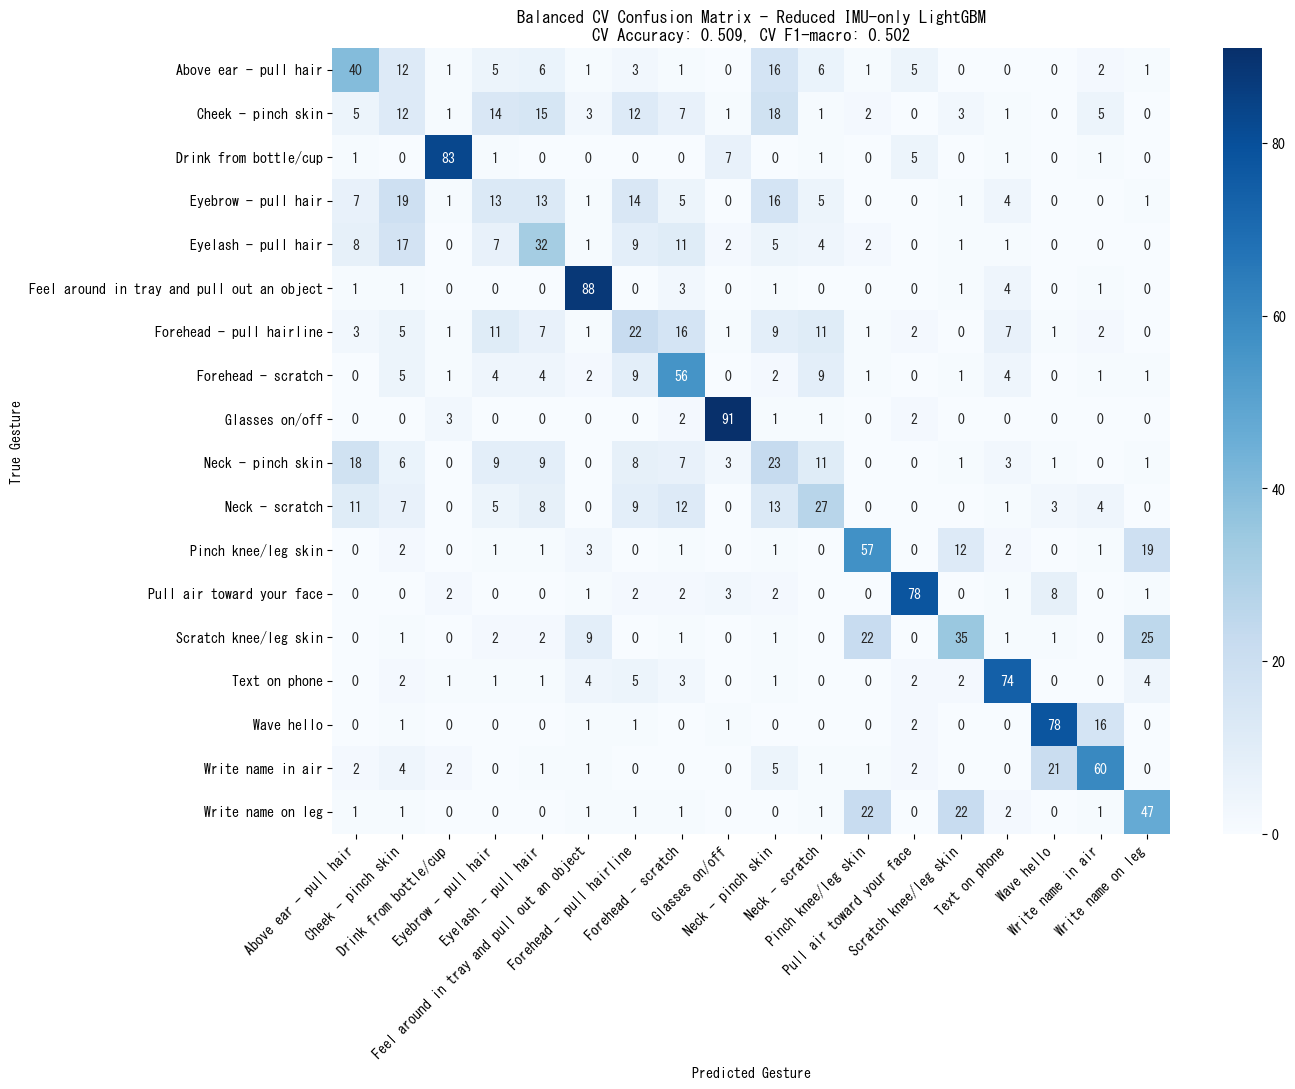


=== 完了 ===
総実行時間: 45.4s


In [35]:
print("="*80)
print("削減後 IMU-only モデル学習")
print("="*80)
(cm_imu_reduced, y_true_imu_reduced, y_pred_imu_reduced, 
 trained_imu_reduced_model, imu_reduced_results) = balanced_cv_confusion_matrix_with_model(
    reduced_imu_model, X_imu_reduced, y_imu_bal, groups_imu_bal, 
    "Reduced IMU-only LightGBM", le_gesture.classes_, n_folds=CFG.n_folds
)


削減後 Full-sensor モデル学習
=== Reduced Full-sensor LightGBM バランスCV混同行列 (n_folds=3) ===
データサイズ: (1681, 486)
被験者グループ数: 79
Fold 1: Train=1122, Val=559
  Accuracy: 0.587, F1-macro: 0.587, Time: 16.5s
Fold 2: Train=1118, Val=563
  Accuracy: 0.595, F1-macro: 0.596, Time: 17.0s
Fold 3: Train=1122, Val=559
  Accuracy: 0.572, F1-macro: 0.552, Time: 17.1s

=== CV結果 ===
CV精度: 0.585
CV F1-macro: 0.581
CV実行時間: 50.5s

=== 最終モデル学習 ===
最終モデル学習時間: 18.6s
学習データサイズ: (1681, 486)


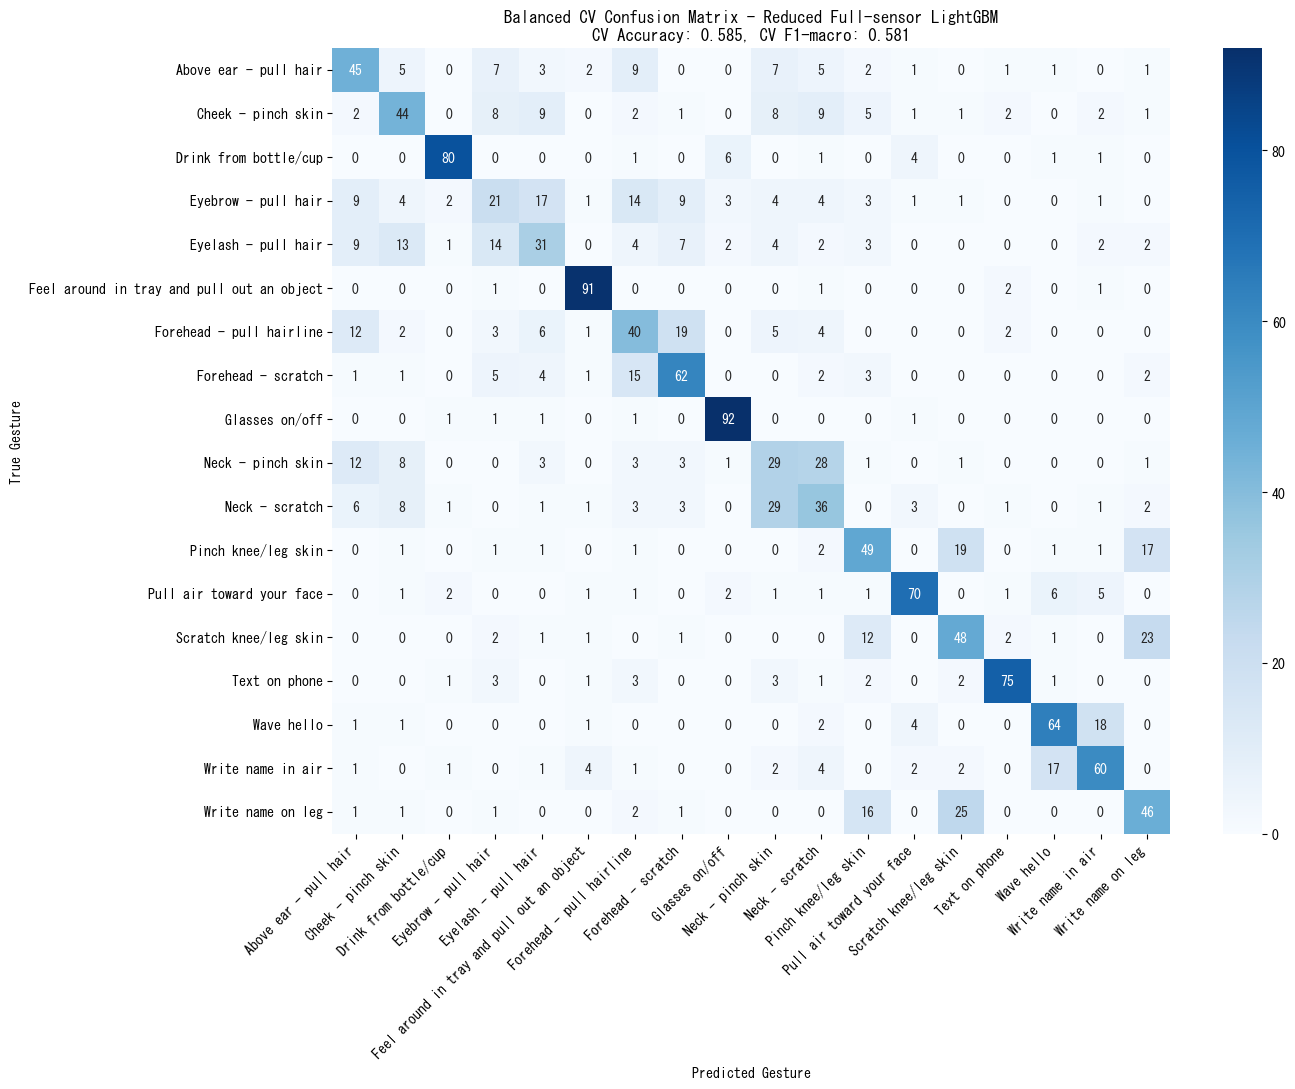


=== 完了 ===
総実行時間: 69.1s


In [36]:
# 削減後Full-sensorモデルの学習・評価  
print("\n" + "="*80)
print("削減後 Full-sensor モデル学習")
print("="*80)

(cm_full_reduced, y_true_full_reduced, y_pred_full_reduced, 
 trained_full_reduced_model, full_reduced_results) = balanced_cv_confusion_matrix_with_model(
    reduced_full_model, X_full_reduced, y_full_bal, groups_full_bal, 
    "Reduced Full-sensor LightGBM", le_gesture.classes_, n_folds=CFG.n_folds
)

# Retry

In [19]:
# 特徴量セット作成
(X_imu_bal_v04, y_imu_bal_v04, groups_imu_bal_v04, 
 X_full_bal_v04, y_full_bal_v04, groups_full_bal_v04) = create_balanced_feature_datasets_v04(train_balanced, train_d)

=== 軽量化特徴量セット作成 ===
IMU-only対象: 1800 sequences
Full-sensor対象: 1681 sequences
IMU-only特徴量構築中...
Full-sensor特徴量構築中...

=== 特徴量セット完成 ===
IMU-only: (1800, 94) (samples × features)
Full-sensor: (1681, 166) (samples × features)


In [23]:
analysis_imu_model_v04 = create_lightweight_model_for_analysis()
analysis_full_model_v04 = create_lightweight_model_for_analysis()

=== IMU-only モデル 学習・分析 ===
=== Lightweight IMU-only LightGBM バランスCV混同行列 (n_folds=3) ===
データサイズ: (1800, 94)
被験者グループ数: 81
Fold 1: Train=1197, Val=603
  Accuracy: 0.471, F1-macro: 0.459, Time: 10.2s
Fold 2: Train=1198, Val=602
  Accuracy: 0.467, F1-macro: 0.463, Time: 8.7s
Fold 3: Train=1205, Val=595
  Accuracy: 0.422, F1-macro: 0.407, Time: 8.9s

=== CV結果 ===
CV精度: 0.453
CV F1-macro: 0.446
CV実行時間: 27.8s

=== 最終モデル学習 ===
最終モデル学習時間: 10.0s
学習データサイズ: (1800, 94)


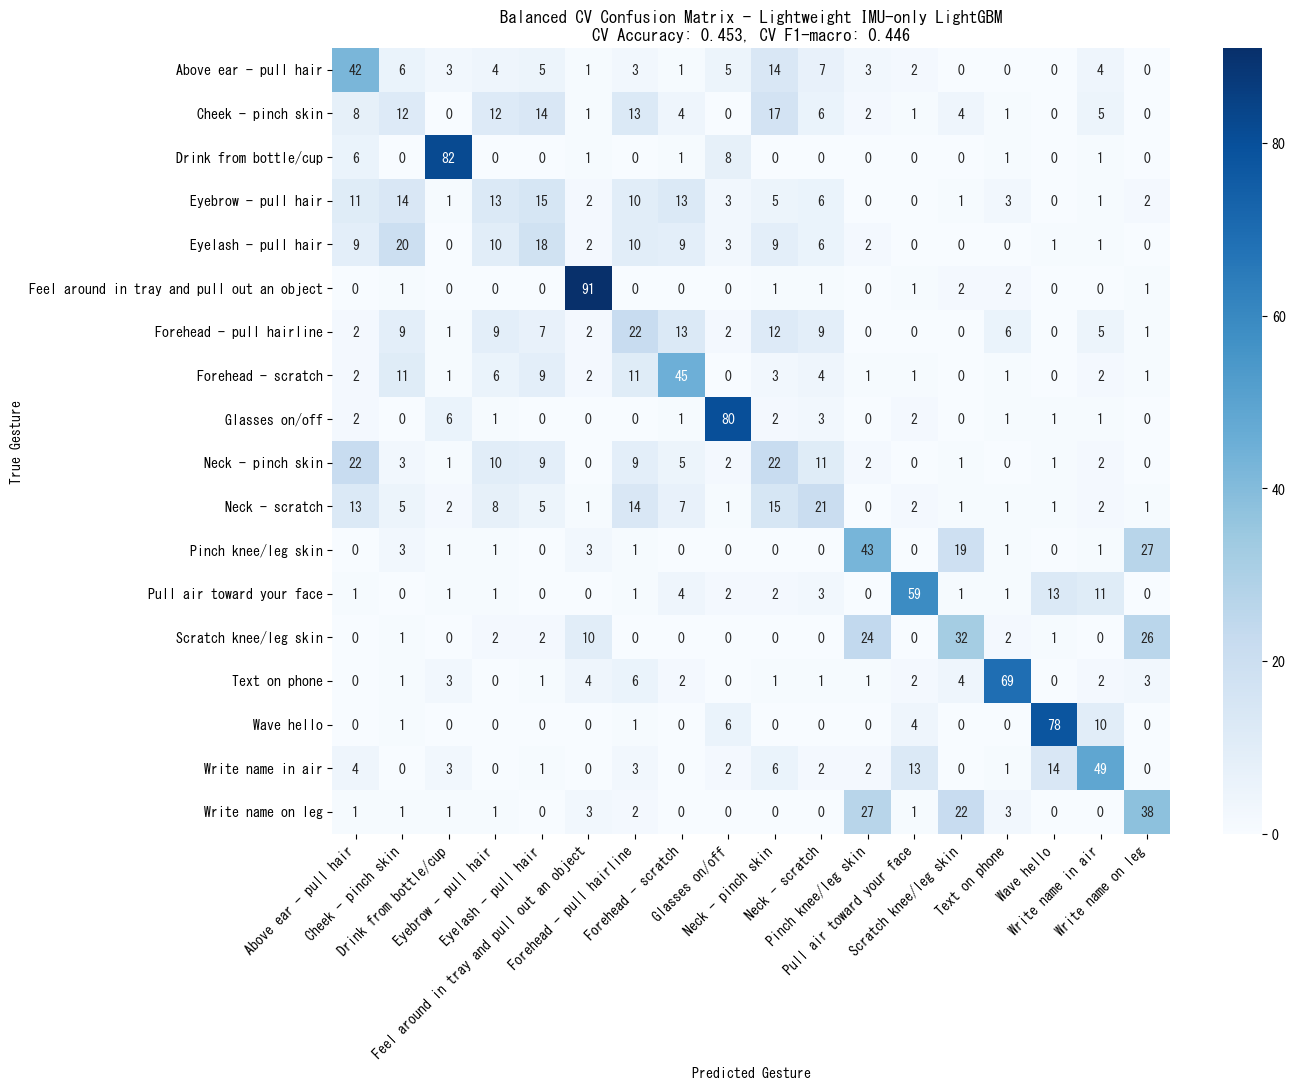


=== 完了 ===
総実行時間: 37.8s


In [24]:
print("=== IMU-only モデル 学習・分析 ===")
(cm_imu_bal_v04, y_true_imu_bal_v04, y_pred_imu_bal_v04, 
 trained_imu_model_v04, imu_results_v04) = balanced_cv_confusion_matrix_with_model(
    analysis_imu_model_v04, X_imu_bal_v04, y_imu_bal_v04, groups_imu_bal_v04, 
    "Lightweight IMU-only LightGBM", le_gesture.classes_, n_folds=CFG.n_folds
)

=== Full-sensor モデル 学習・分析 ===
=== Lightweight Full-sensor LightGBM バランスCV混同行列 (n_folds=3) ===
データサイズ: (1681, 166)
被験者グループ数: 79
Fold 1: Train=1122, Val=559
  Accuracy: 0.556, F1-macro: 0.552, Time: 9.4s
Fold 2: Train=1118, Val=563
  Accuracy: 0.547, F1-macro: 0.545, Time: 9.9s
Fold 3: Train=1122, Val=559
  Accuracy: 0.517, F1-macro: 0.502, Time: 9.8s

=== CV結果 ===
CV精度: 0.540
CV F1-macro: 0.535
CV実行時間: 29.1s

=== 最終モデル学習 ===
最終モデル学習時間: 10.8s
学習データサイズ: (1681, 166)


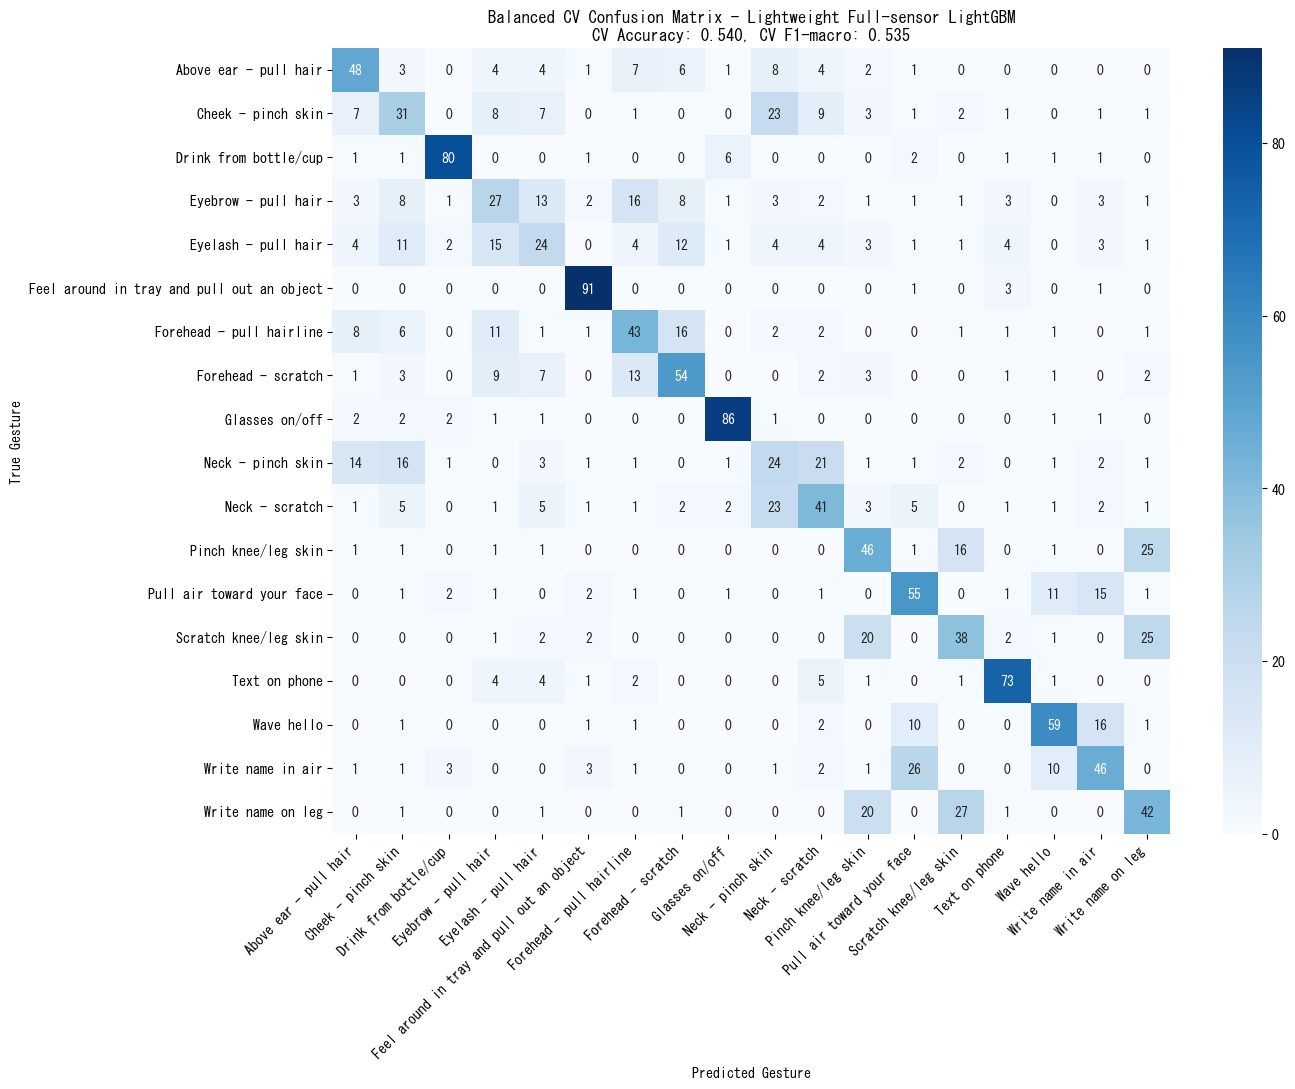


=== 完了 ===
総実行時間: 39.9s


In [25]:
print("=== Full-sensor モデル 学習・分析 ===")
(cm_full_bal_v04, y_true_full_bal_v04, y_pred_full_bal_v04, 
 trained_full_model_v04, full_results_v04) = balanced_cv_confusion_matrix_with_model(
    analysis_full_model_v04, X_full_bal_v04, y_full_bal_v04, groups_full_bal_v04, 
    "Lightweight Full-sensor LightGBM", le_gesture.classes_, n_folds=CFG.n_folds
)